In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Churn_modelling

/content/drive/MyDrive/Churn_modelling


# Import Packages

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [4]:
df = pd.read_csv("cleaned_customer_data.csv")

In [5]:
df.columns

Index(['customer_id', 'name', 'gender', 'age', 'salary', 'location_id',
       'churned', 'account_id', 'tenure', 'balance', 'num_products',
       'has_credit_card', 'is_active', 'geography'],
      dtype='object')

In [6]:
str_cols = df.select_dtypes('object').columns.tolist()
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print('String columns cleaned:', str_cols)

String columns cleaned: ['name', 'gender', 'account_id', 'geography']


In [7]:
def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    """Bins and label columns derived directly from the EDA phase."""
    df = df.copy()

    # Age groups (non-linear churn: 46-60 bucket at 51 %)
    df['age_group'] = pd.cut(
        df['age'], bins=[17, 25, 35, 45, 60, 100], right=True,
        labels=['18-25', '26-35', '36-45', '46-60', '60+']
    )

    # Salary brackets (uniform distribution -- weak churn signal)
    df['salary_bracket'] = pd.cut(
        df['salary'], bins=[0, 50000, 100000, 150000, 200001], right=False,
        labels=['low', 'medium', 'high', 'very_high']
    )

    # Tenure groups
    df['tenure_group'] = pd.cut(
        df['tenure'], bins=[-1, 2, 5, 7, 10], right=True,
        labels=['new (0-2)', 'mid (3-5)', 'senior (6-7)', 'veteran (8-10)']
    )

    # Balance presence flag (13.8 % vs 24.1 % churn split)
    df['has_balance'] = (df['balance'].notna() & (df['balance'] > 0)).astype(int)

    # Human-readable label columns (used in EDA charts)
    df['churn_label']          = df['churned'].map({0: 'Retained', 1: 'Churned'})
    df['has_credit_card_label'] = df['has_credit_card'].map({1: 'Has Card', 0: 'No Card'})
    df['is_active_label']      = df['is_active'].map({1: 'Active', 0: 'Inactive'})

    return df


print('add_eda_features  defined')

add_eda_features  defined


In [8]:
def add_financial_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """Relative wealth and product-load financial ratios."""
    df  = df.copy()
    bal = df['balance'].fillna(0) if 'balance' in df.columns else pd.Series(0, index=df.index)
    if 'salary' in df.columns:
        df['balance_to_salary']   = bal / (df['salary'] + 1)        # +1 guards salary == 0
    if 'num_products' in df.columns:
        df['balance_per_product'] = bal / df['num_products'].clip(lower=1)
    return df


print('add_financial_ratios  defined')

add_financial_ratios  defined


In [9]:
def add_lifecycle_features(df: pd.DataFrame) -> pd.DataFrame:
    """Age at account opening and product adoption velocity."""
    df = df.copy()
    if {'age', 'tenure'} <= set(df.columns):
        df['age_when_joined']     = df['age'] - df['tenure']
    if {'num_products', 'tenure'} <= set(df.columns):
        df['products_per_tenure'] = df['num_products'] / (df['tenure'] + 1)
    return df


print('add_lifecycle_features  defined')

add_lifecycle_features  defined


In [10]:
def add_risk_segments(df: pd.DataFrame) -> pd.DataFrame:
    """Binary risk flags for EDA-identified high-churn customer segments."""
    df = df.copy()
    if 'age' in df.columns:
        df['is_senior_risk']          = ((df['age'] >= 45) & (df['age'] <= 60)).astype(int)
    if 'num_products' in df.columns:
        df['is_extreme_product_risk'] = (df['num_products'] >= 3).astype(int)
        df['is_single_product']       = (df['num_products'] == 1).astype(int)
    if {'is_active', 'age'} <= set(df.columns):
        df['inactive_senior']         = ((df['is_active'] == 0) & (df['age'] >= 45)).astype(int)
    return df


print('add_risk_segments  defined')

add_risk_segments  defined


In [11]:
def add_engagement_features(df: pd.DataFrame) -> pd.DataFrame:
    """Composite engagement score [0-1] and deep-inactivity risk flag."""
    df = df.copy()
    required = {'is_active', 'has_credit_card', 'num_products'}
    if required <= set(df.columns):
        df['engagement_score']   = (
            df['is_active'] + df['has_credit_card'] + (df['num_products'] / 4.0)
        ) / 3.0
        df['high_risk_inactive'] = (
            (df['is_active'] == 0) & (df['has_credit_card'] == 0)
        ).astype(int)
    return df


print('add_engagement_features  defined')

add_engagement_features  defined


In [12]:
def encode_categoricals(df: pd.DataFrame, drop_identifiers: bool = True) -> pd.DataFrame:
    """Binary-encode gender, one-hot geography, drop leaky ID columns."""
    df = df.copy()
    if 'gender' in df.columns:
        df['is_female'] = (df['gender'].str.lower() == 'female').astype(int)
    if 'geography' in df.columns:
        geo_dummies = pd.get_dummies(df['geography'], prefix='geo', drop_first=True, dtype=int)
        df = pd.concat([df, geo_dummies], axis=1)
    if drop_identifiers:
        drop_cols = ['customer_id', 'account_id', 'name', 'gender', 'geography', 'location_id',
                     'churn_label', 'has_credit_card_label', 'is_active_label']
        df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    return df


print('encode_categoricals  defined')

encode_categoricals  defined


In [13]:
def build_churn_features(df: pd.DataFrame, drop_identifiers: bool = True) -> pd.DataFrame:
    """
    Complete feature-engineering pipeline via pandas .pipe().

    Usage
    -----
    df_model = build_churn_features(df)                           # standard
    df_model = build_churn_features(df, drop_identifiers=False)   # keep IDs

    Each step is also usable standalone:
        df.pipe(add_eda_features).pipe(add_risk_segments)
    """
    return (
        df
        .pipe(add_eda_features)
        .pipe(add_financial_ratios)
        .pipe(add_lifecycle_features)
        .pipe(add_risk_segments)
        .pipe(add_engagement_features)
        .pipe(lambda d: encode_categoricals(d, drop_identifiers=drop_identifiers))
    )


print('build_churn_features  defined')

build_churn_features  defined


## Run Pipeline & Validate

In [14]:
df_featured = build_churn_features(df)

original_modelling_cols = [c for c in df.columns
                           if c not in ['customer_id', 'account_id', 'name',
                                        'gender', 'geography', 'location_id']]
new_cols = [c for c in df_featured.columns if c not in df.columns]

print(f'Original  : {df.shape[0]:,} rows x {df.shape[1]:>2} cols')
print(f'Engineered: {df_featured.shape[0]:,} rows x {df_featured.shape[1]:>2} cols')
print(f'New features added: {len(new_cols)}')
print()
print('New columns:')
for c in new_cols:
    print(f'  {c}')

Original  : 10,000 rows x 14 cols
Engineered: 10,000 rows x 28 cols
New features added: 20

New columns:
  age_group
  salary_bracket
  tenure_group
  has_balance
  balance_to_salary
  balance_per_product
  age_when_joined
  products_per_tenure
  is_senior_risk
  is_extreme_product_risk
  is_single_product
  inactive_senior
  engagement_score
  high_risk_inactive
  is_female
  geo_france
  geo_germany
  geo_spain
  geo_uk
  geo_usa


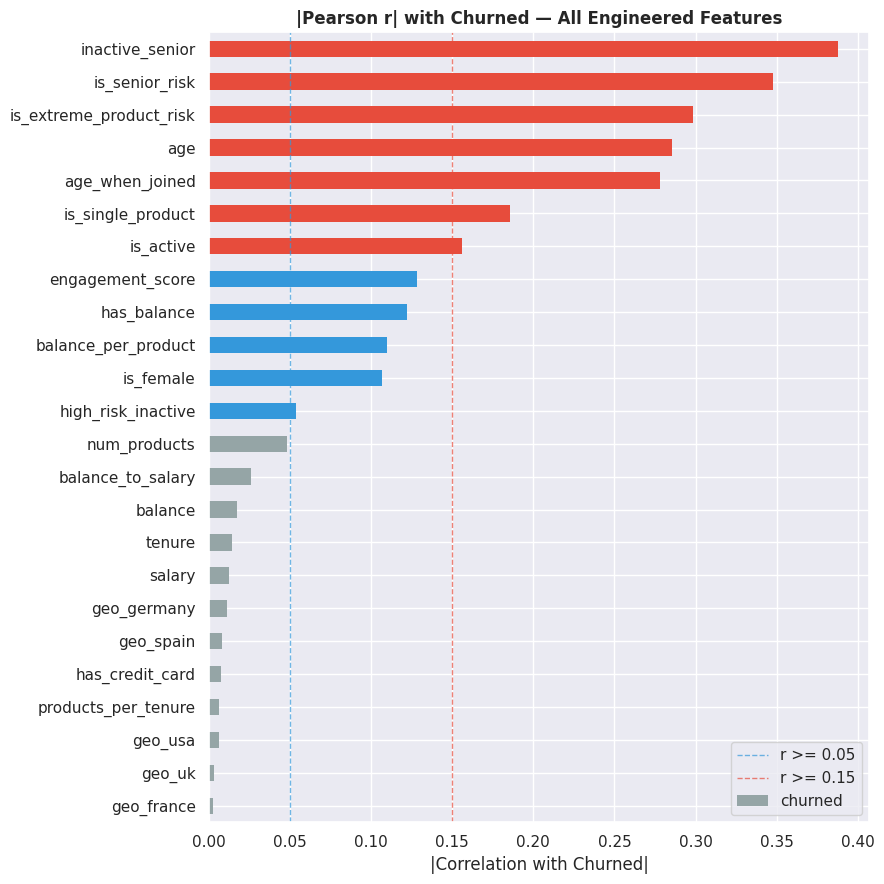

In [15]:
# Correlation of all features with churned
corr = (
    df_featured
    .select_dtypes(include='number')
    .corr()['churned']
    .drop('churned')
    .abs()
    .sort_values(ascending=True)
)

palette = ['#e74c3c' if v >= 0.15 else '#3498db' if v >= 0.05 else '#95a5a6'
           for v in corr.values]

fig, ax = plt.subplots(figsize=(9, 9))
corr.plot(kind='barh', ax=ax, color=palette, edgecolor='none')
ax.axvline(0.05, color='#3498db', linestyle='--', lw=1, alpha=0.7, label='r >= 0.05')
ax.axvline(0.15, color='#e74c3c', linestyle='--', lw=1, alpha=0.7, label='r >= 0.15')
ax.set_title('|Pearson r| with Churned — All Engineered Features',
             fontsize=12, fontweight='bold')
ax.set_xlabel('|Correlation with Churned|')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Null / Inf audit
null_audit = df_featured.isnull().sum()
inf_audit  = df_featured.select_dtypes('number').apply(lambda c: np.isinf(c).sum())
audit      = pd.DataFrame({'nulls': null_audit, 'infs': inf_audit})
problems   = audit[(audit['nulls'] > 0) | (audit['infs'] > 0)]

if problems.empty:
    print('No unexpected nulls or infinities in engineered features.')
else:
    print('Columns with issues:')
    display(problems)

Columns with issues:


,nulls,infs
balance,3617,0.0


## Export Modelling-Ready Dataset

In [17]:
output_path = r'D:\code\engineered_customer_data.csv'
df_featured.to_csv(output_path, index=False)
print(f'Saved to  : {output_path}')
print(f'Shape     : {df_featured.shape[0]:,} rows x {df_featured.shape[1]} columns')
print(f'Churned 0 : {(df_featured["churned"]==0).sum():,}')
print(f'Churned 1 : {(df_featured["churned"]==1).sum():,}')

Saved to  : D:\code\engineered_customer_data.csv
Shape     : 10,000 rows x 28 columns
Churned 0 : 7,963
Churned 1 : 2,037


In [18]:
# Apply feature engineering — df_final is used throughout the EDA cells below
df_final = build_churn_features(df, drop_identifiers=False)
print(f'df_final ready: {df_final.shape[0]:,} rows x {df_final.shape[1]} cols')
df_final.head(3)

df_final ready: 10,000 rows x 37 cols


,customer_id,name,gender,age,salary,location_id,churned,account_id,tenure,balance,...,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female,geo_france,geo_germany,geo_spain,geo_uk,geo_usa
0,15634602,Hargrave,female,42,101348.88,2,1,A15634602SID,2,NaN,...,1,0,0.750000,0,1,1,0,0,0,0
1,15647311,Hill,female,41,112542.58,6,0,A15647311SID,1,83807.86,...,1,0,0.416667,0,1,0,0,0,0,1
2,15619304,Onio,female,42,113931.57,4,1,A15619304SID,8,159660.80,...,0,0,0.583333,0,1,0,0,0,1,0


# Preliminary Analysis

In [19]:
missing = df_final.isnull().sum()
missing[missing > 0]

,0
balance,3617


In [20]:
missing_rows = df_final.isnull().any(axis=1).sum()
print(f'Rows with missing values: {missing_rows}')
print(f'Percentage: {missing_rows / df_final.shape[0] * 100:.2f}%')

Rows with missing values: 3617
Percentage: 36.17%


In [21]:
print('Balance null count:', df_final['balance'].isnull().sum())
print('These are likely zero-balance accounts — investigate further below.')

Balance null count: 3617
These are likely zero-balance accounts — investigate further below.


In [22]:
print('Duplicate rows:', df_final.duplicated().sum())
print('Duplicate CustomerIds:', df_final['customer_id'].duplicated().sum())

Duplicate rows: 0
Duplicate CustomerIds: 0


In [23]:
df_final.dtypes

,0
customer_id,int64
name,object
gender,object
age,int64
salary,float64
location_id,int64
churned,int64
account_id,object
tenure,int64
balance,float64


In [24]:
num_cols = ['age', 'salary', 'tenure', 'balance']
cat_cols = ['gender', 'geography', 'num_products', 'has_credit_card', 'is_active',
            'age_group', 'salary_bracket', 'tenure_group', 'has_balance', 'churned']

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (4): ['age', 'salary', 'tenure', 'balance']
Categorical columns (10): ['gender', 'geography', 'num_products', 'has_credit_card', 'is_active', 'age_group', 'salary_bracket', 'tenure_group', 'has_balance', 'churned']


In [25]:
df_final[num_cols].describe()

,age,salary,tenure,balance
count,10000.000000,10000.000000,10000.000000,6383.000000
mean,38.921800,100090.239881,5.012800,119827.493793
std,10.487806,57510.492818,2.892174,30095.056462
min,18.000000,11.580000,0.000000,3768.690000
25%,32.000000,51002.110000,3.000000,100181.975000
50%,37.000000,100193.915000,5.000000,119839.690000
75%,44.000000,149388.247500,7.000000,139512.290000
max,92.000000,199992.480000,10.000000,250898.090000


In [26]:
(
    df_final[['gender', 'geography', 'age_group', 'salary_bracket',
              'tenure_group', 'has_credit_card_label', 'is_active_label', 'churn_label']]
    .astype('object')
    .describe(include='object')
    .T
)

,count,unique,top,freq
gender,10000,2,male,5457
geography,10000,6,france,1714
age_group,10000,5,36-45,3736
salary_bracket,10000,4,high,2555
tenure_group,10000,4,mid (3-5),3010
has_credit_card_label,10000,2,Has Card,7055
is_active_label,10000,2,Active,5151
churn_label,10000,2,Retained,7963


# Functions to Perform Analysis

In [27]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins='auto'):
    """Univariate analysis for a numeric column — KDE, Boxplot, Histogram."""
    fig = plt.figure(figsize=(15, 10))
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    sns.kdeplot(data=dataframe, x=column_name, hue=cat_col, ax=ax1, fill=True, alpha=0.4)
    ax1.set_title(f'KDE Plot — {column_name}')
    sns.boxplot(data=dataframe, x=column_name, hue=cat_col, ax=ax2)
    ax2.set_title(f'Boxplot — {column_name}')
    sns.histplot(data=dataframe, x=column_name, bins=bins, hue=cat_col, kde=True, ax=ax3)
    ax3.set_title(f'Histogram — {column_name}')
    plt.suptitle(f'Numerical Analysis: {column_name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    """Bivariate analysis — categorical predictor vs numeric column."""
    fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax[0][0])
    ax[0][0].set_title(f'Mean {num_column} by {cat_column_1}')
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax[0][1])
    ax[0][1].set_title(f'Boxplot: {num_column} by {cat_column_1}')
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax[1][0])
    ax[1][0].set_title(f'Violin: {num_column} by {cat_column_1}')
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax[1][1], alpha=0.3, size=2)
    ax[1][1].set_title(f'Strip: {num_column} by {cat_column_1}')
    plt.suptitle(f'{cat_column_1} vs {num_column}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    """Categorical column profiling — counts, percentages, count plot."""
    display(
        pd.DataFrame({
            'Count': dataframe[column_name].value_counts(),
            'Percentage': (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100).round(2).astype('str').add('%')
            )
        })
    )
    print('*' * 50)
    print(f'Unique categories in "{column_name}": {dataframe[column_name].unique().tolist()}')
    print('*' * 50)
    print(f'Number of categories: {dataframe[column_name].nunique()}')
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=dataframe, x=column_name, ax=ax,
                  order=dataframe[column_name].value_counts().index)
    ax.set_title(f'Count Plot — {column_name}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    """3-way analysis — numeric target vs two categorical features."""
    fig, ax = plt.subplots(2, 2, figsize=(16, 8))
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, hue=cat_column_2, ax=ax[0][0])
    ax[0][0].set_title(f'Bar: {num_column} | {cat_column_1} × {cat_column_2}')
    ax[0][0].legend(bbox_to_anchor=(1.02, 1), loc=2, fontsize=8)
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, hue=cat_column_2, gap=0.1, ax=ax[0][1])
    ax[0][1].set_title(f'Box: {num_column} | {cat_column_1} × {cat_column_2}')
    ax[0][1].legend(bbox_to_anchor=(1.02, 1), loc=2, fontsize=8)
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, hue=cat_column_2, gap=0.1, ax=ax[1][0])
    ax[1][0].set_title(f'Violin: {num_column} | {cat_column_1} × {cat_column_2}')
    ax[1][0].legend(bbox_to_anchor=(1.02, 1), loc=2, fontsize=8)
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, hue=cat_column_2,
                  dodge=True, ax=ax[1][1], alpha=0.3, size=2)
    ax[1][1].set_title(f'Strip: {num_column} | {cat_column_1} × {cat_column_2}')
    ax[1][1].legend(bbox_to_anchor=(1.02, 1), loc=2, fontsize=8)
    plt.suptitle(f'Multivariate: {num_column} | {cat_column_1} × {cat_column_2}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def chi_2_test(dataframe, col1, col2, alpha=0.05):
    """Chi-squared test of independence between two categorical columns."""
    data = dataframe.loc[:, [col1, col2]].dropna()
    contingency_table = pd.crosstab(data[col1], data[col2])
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(f'Chi²  p-value: {p_val:.6f}')
    if p_val <= alpha:
        print(f'  ✅ Reject H₀ — Significant association between "{col1}" and "{col2}".')
    else:
        print(f'  ❌ Fail to reject H₀ — No significant association between "{col1}" and "{col2}".')


def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    """One-way ANOVA — tests if means of num_col differ across cat_col groups."""
    data = dataframe.loc[:, [num_col, cat_col]].dropna()
    groups = [group[num_col].values for _, group in data.groupby(cat_col)]
    f_stat, p_val = f_oneway(*groups)
    print(f'ANOVA  F-stat: {f_stat:.4f}  |  p-value: {p_val:.6f}')
    if p_val <= alpha:
        print(f'  ✅ Reject H₀ — Significant relationship between "{num_col}" and "{cat_col}".')
    else:
        print(f'  ❌ Fail to reject H₀ — No significant relationship between "{num_col}" and "{cat_col}".')


def test_for_normality(dataframe, column_name, alpha=0.05):
    """Jarque-Bera test for normality."""
    data = dataframe[column_name].dropna()
    print('Jarque-Bera Test for Normality')
    _, p_val = jarque_bera(data)
    print(f'  p-value: {p_val:.6f}')
    if p_val <= alpha:
        print('  ✅ Reject H₀ — Data is NOT normally distributed.')
    else:
        print('  ❌ Fail to reject H₀ — Data is normally distributed.')


def churn_rate_by_category(dataframe, cat_col):
    """Compute and plot churn rate (%) per category."""
    churn_rate = (
        dataframe.groupby(cat_col)['churned']
        .mean().mul(100).round(2)
        .reset_index()
        .rename(columns={'churned': 'churn_rate_%'})
        .sort_values('churn_rate_%', ascending=False)
    )
    display(churn_rate)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=churn_rate, x=cat_col, y='churn_rate_%', ax=ax)
    ax.axhline(dataframe['churned'].mean() * 100, color='red',
               linestyle='--', label='Overall Churn Rate')
    ax.set_title(f'Churn Rate (%) by {cat_col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


print('All analysis functions defined.')

All analysis functions defined.


# Column Wise Analysis

In [28]:
df_final.columns.tolist()

['customer_id',
 'name',
 'gender',
 'age',
 'salary',
 'location_id',
 'churned',
 'account_id',
 'tenure',
 'balance',
 'num_products',
 'has_credit_card',
 'is_active',
 'geography',
 'age_group',
 'salary_bracket',
 'tenure_group',
 'has_balance',
 'churn_label',
 'has_credit_card_label',
 'is_active_label',
 'balance_to_salary',
 'balance_per_product',
 'age_when_joined',
 'products_per_tenure',
 'is_senior_risk',
 'is_extreme_product_risk',
 'is_single_product',
 'inactive_senior',
 'engagement_score',
 'high_risk_inactive',
 'is_female',
 'geo_france',
 'geo_germany',
 'geo_spain',
 'geo_uk',
 'geo_usa']

## Churned — Target Variable (Demographic sheet)

In [29]:
df_final['churned'].dtype

dtype('int64')

,Count,Percentage
churn_label,,
Retained,7963,79.63%
Churned,2037,20.37%


**************************************************
Unique categories in "churn_label": ['Churned', 'Retained']
**************************************************
Number of categories: 2


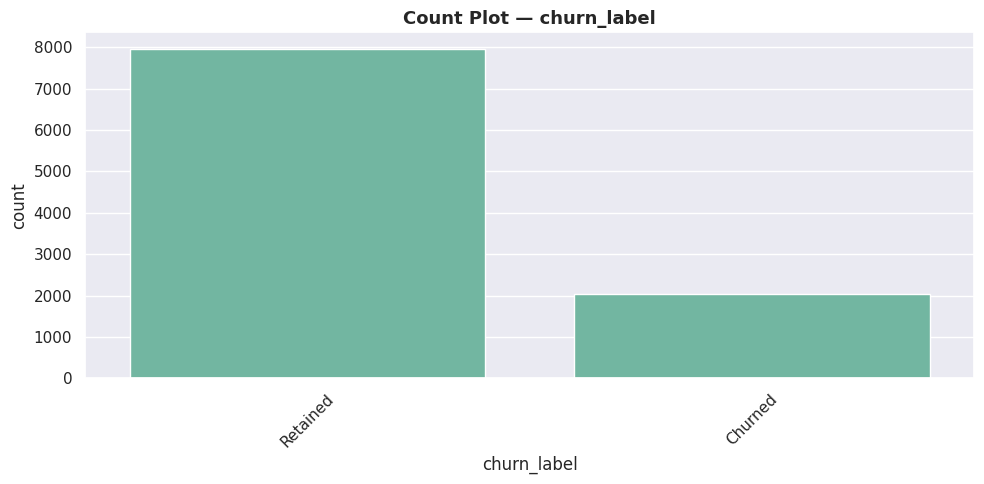

In [30]:
categorical_analysis(df_final, 'churn_label')

In [31]:
churn_rate = df_final['churned'].mean() * 100
print(f'Overall Churn Rate : {churn_rate:.2f}%')
print(f'Retained           : {100 - churn_rate:.2f}%')

Overall Churn Rate : 20.37%
Retained           : 79.63%


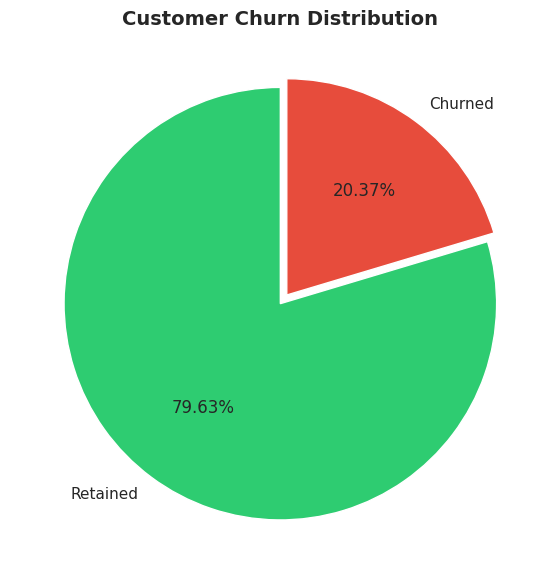

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
df_final['churn_label'].value_counts().plot.pie(
    autopct='%1.2f%%', startangle=90, ax=ax,
    colors=['#2ecc71', '#e74c3c'], explode=[0, 0.05]
)
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observations**:
1. Dataset is imbalanced — ~79.63% retained vs ~20.37% churned (≈ 4:1 ratio).
2. Class imbalance should be addressed during modelling (SMOTE, class_weight).


## Age (Demographic sheet)

In [33]:
df_final['age'].dtype

dtype('int64')

In [34]:
df_final['age'].describe()

,age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


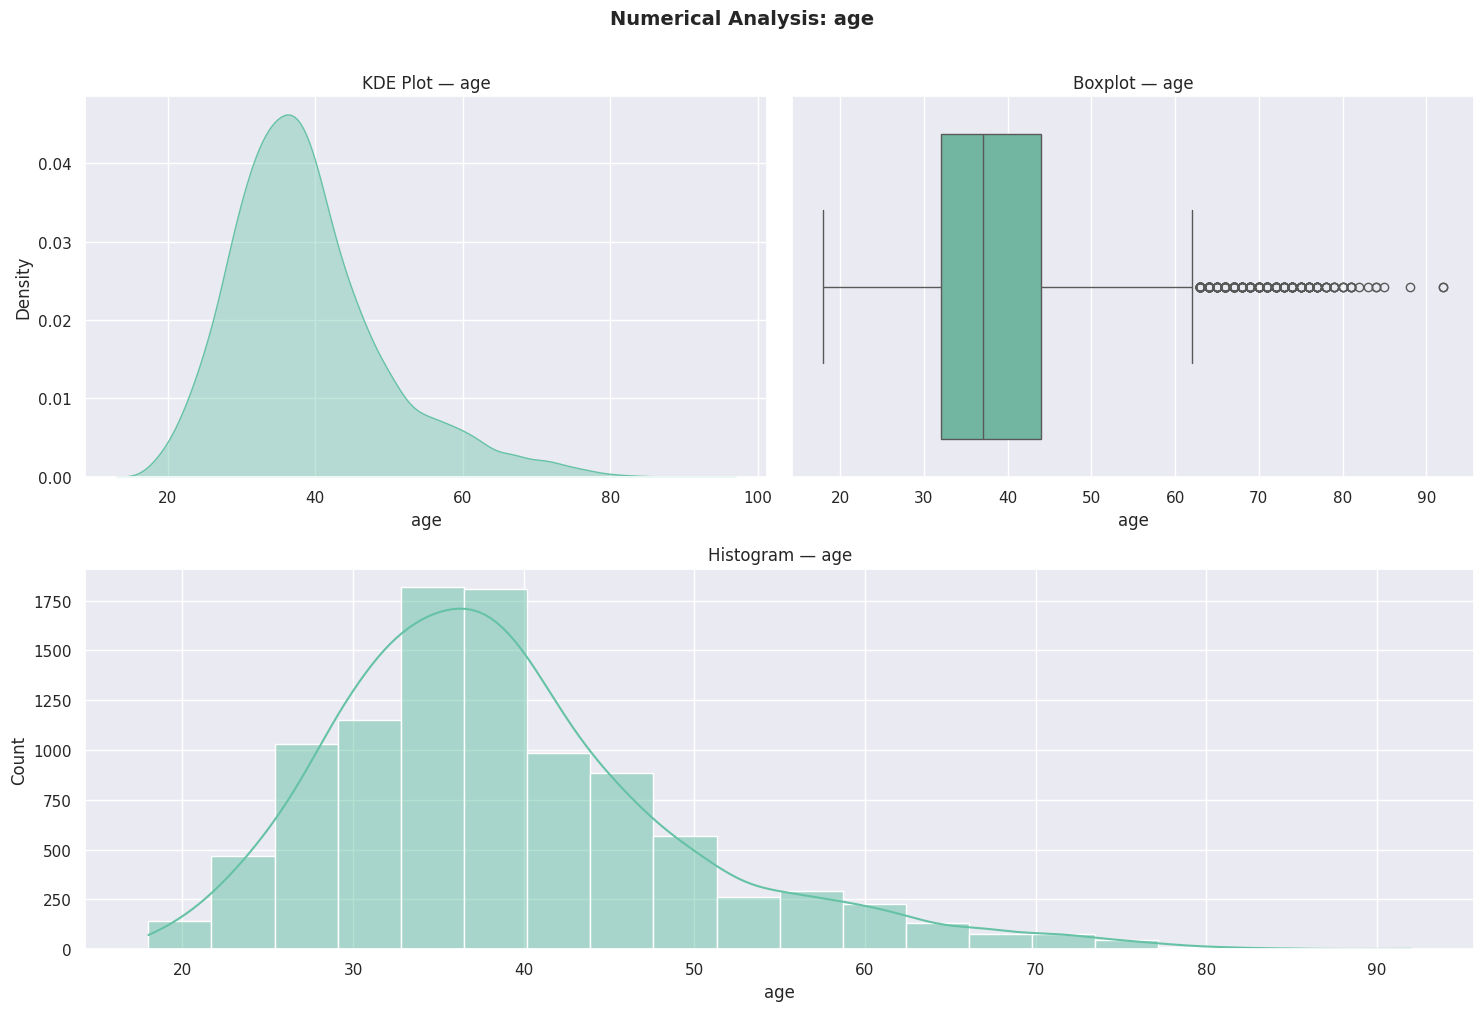

In [35]:
numerical_analysis(df_final, 'age', bins=20)

In [36]:
test_for_normality(df_final, 'age')

Jarque-Bera Test for Normality
  p-value: 0.000000
  ✅ Reject H₀ — Data is NOT normally distributed.


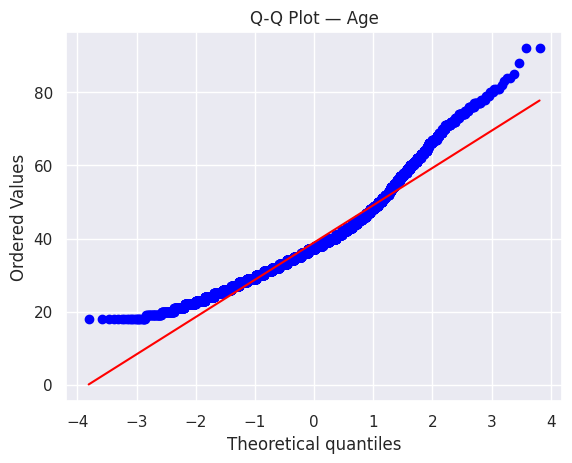

In [37]:
probplot(df_final['age'], plot=plt)
plt.title('Q-Q Plot — Age')
plt.show()

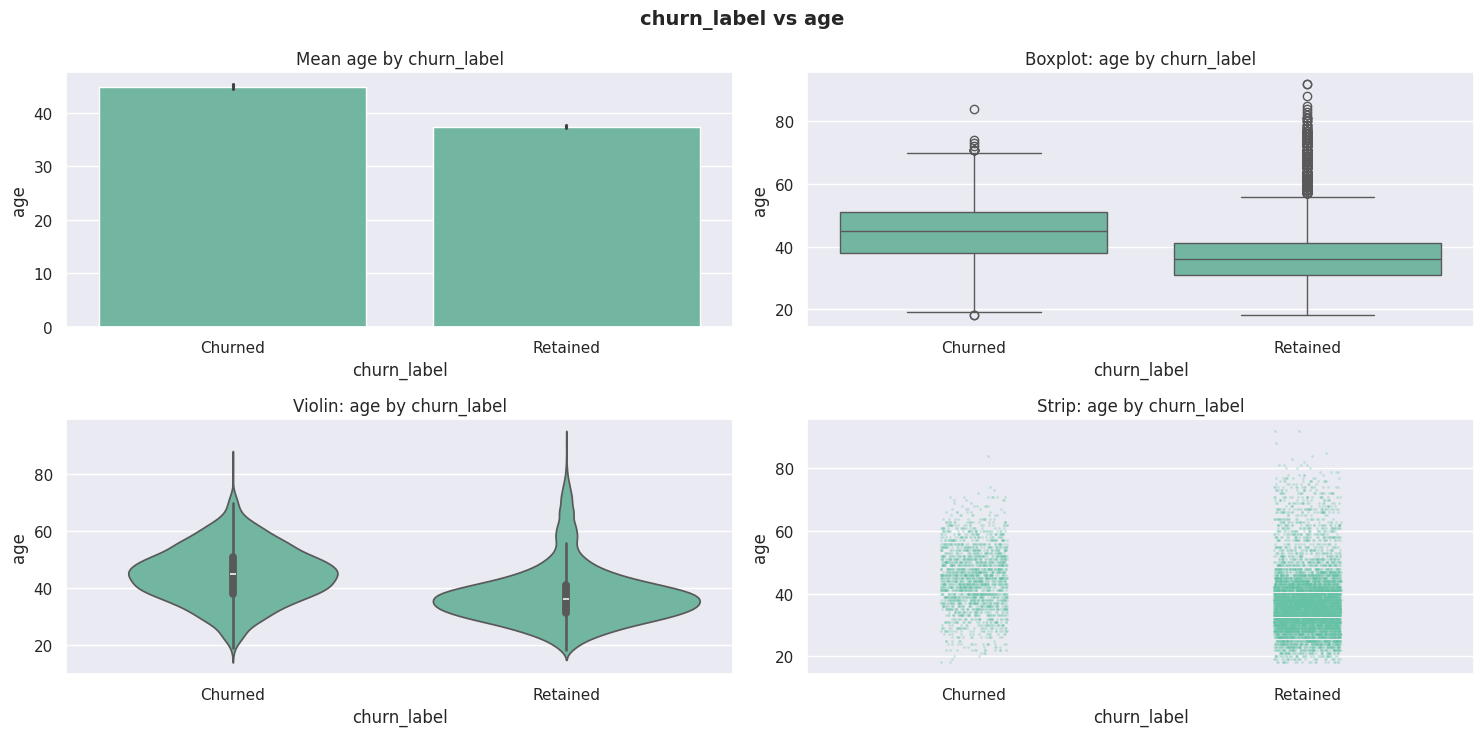

In [38]:
numerical_categorical_analysis(df_final, 'churn_label', 'age')

In [39]:
anova_test(df_final, 'age', 'churn_label')

ANOVA  F-stat: 886.0633  |  p-value: 0.000000
  ✅ Reject H₀ — Significant relationship between "age" and "churn_label".


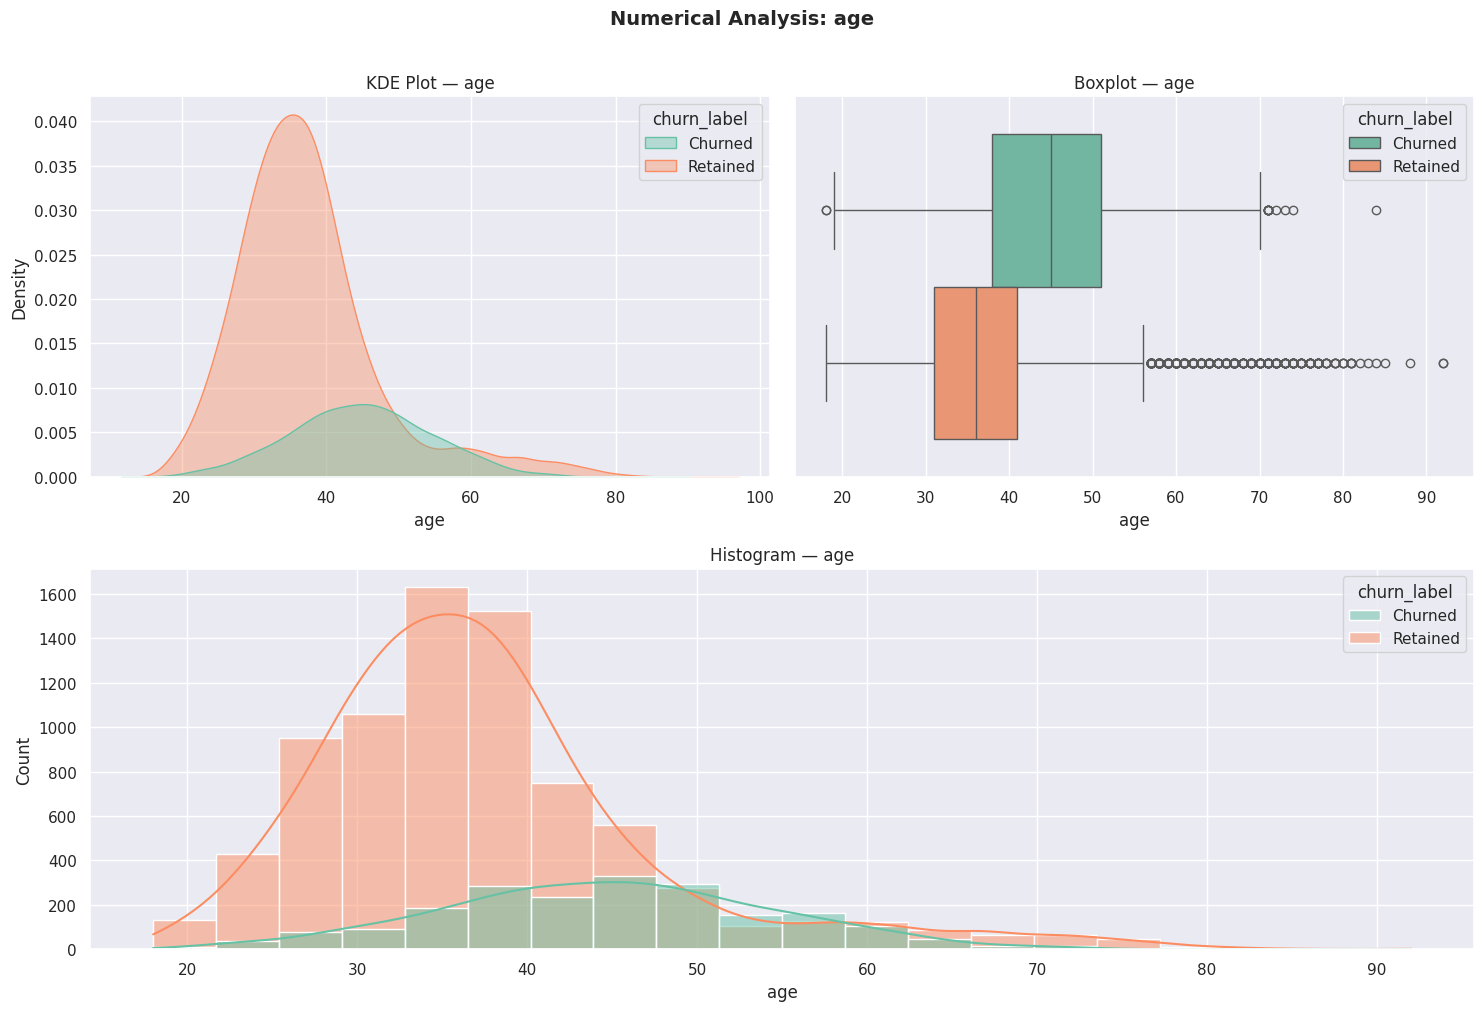

In [40]:
numerical_analysis(df_final, 'age', cat_col='churn_label', bins=20)

,Count,Percentage
age_group,,
36-45,3736,37.36%
26-35,3542,35.42%
46-60,1647,16.47%
18-25,611,6.11%
60+,464,4.64%


**************************************************
Unique categories in "age_group": ['36-45', '46-60', '26-35', '18-25', '60+']
**************************************************
Number of categories: 5


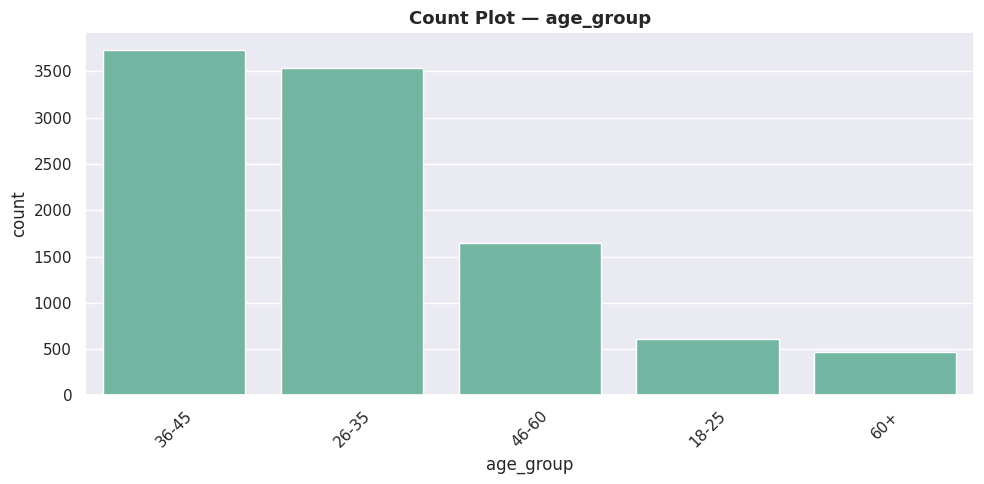

In [41]:
categorical_analysis(df_final, 'age_group')

,age_group,churn_rate_%
3,46-60,51.12
4,60+,24.78
2,36-45,19.62
1,26-35,8.50
0,18-25,7.53


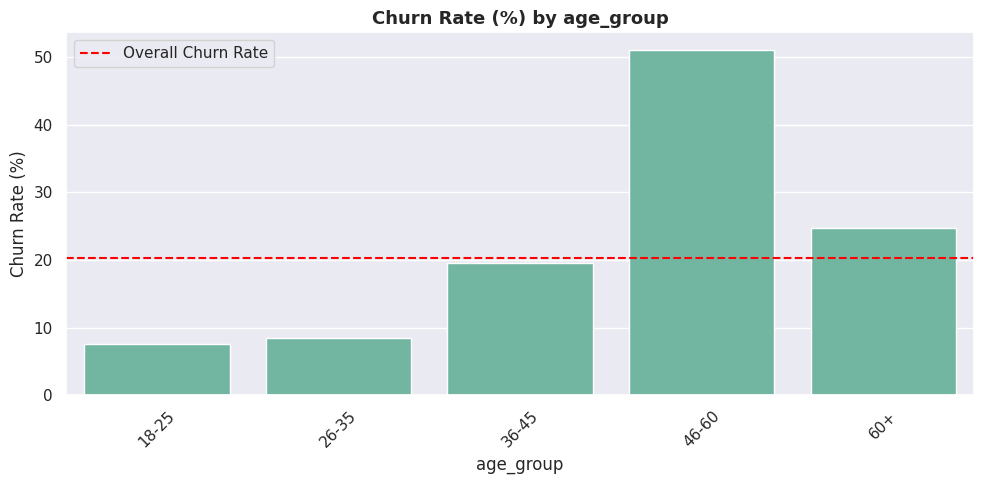

In [42]:
churn_rate_by_category(df_final, 'age_group')

In [43]:
chi_2_test(df_final, 'age_group', 'churn_label')

Chi²  p-value: 0.000000
  ✅ Reject H₀ — Significant association between "age_group" and "churn_label".


**Observations**:
- Churned customers are significantly **older** (mean ~44.8 yrs vs ~37.4 yrs).
- The **46-60** age group has the highest churn rate (~51%).
- Age is the **strongest individual predictor** of churn (corr = 0.285).


## Gender (Demographic sheet)

,Count,Percentage
gender,,
male,5457,54.57%
female,4543,45.43%


**************************************************
Unique categories in "gender": ['female', 'male']
**************************************************
Number of categories: 2


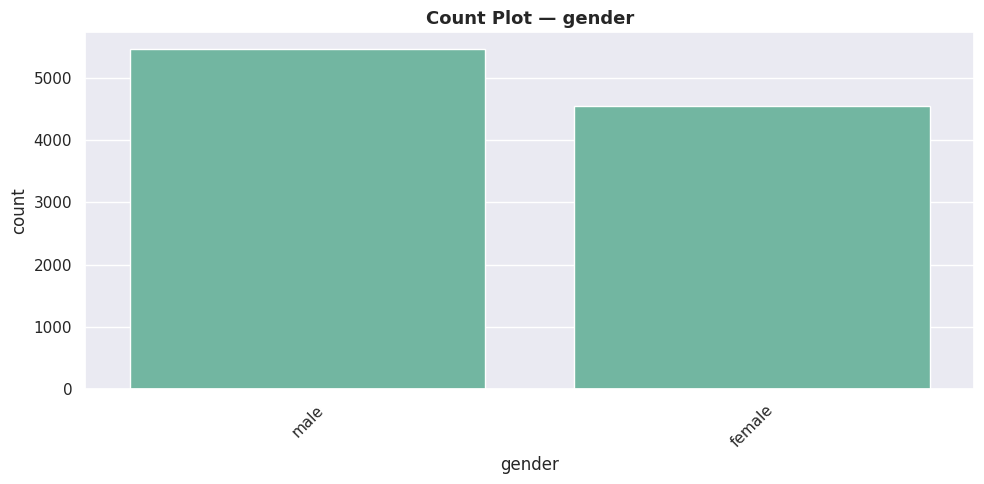

In [44]:
categorical_analysis(df_final, 'gender')

,gender,churn_rate_%
0,female,25.07
1,male,16.46


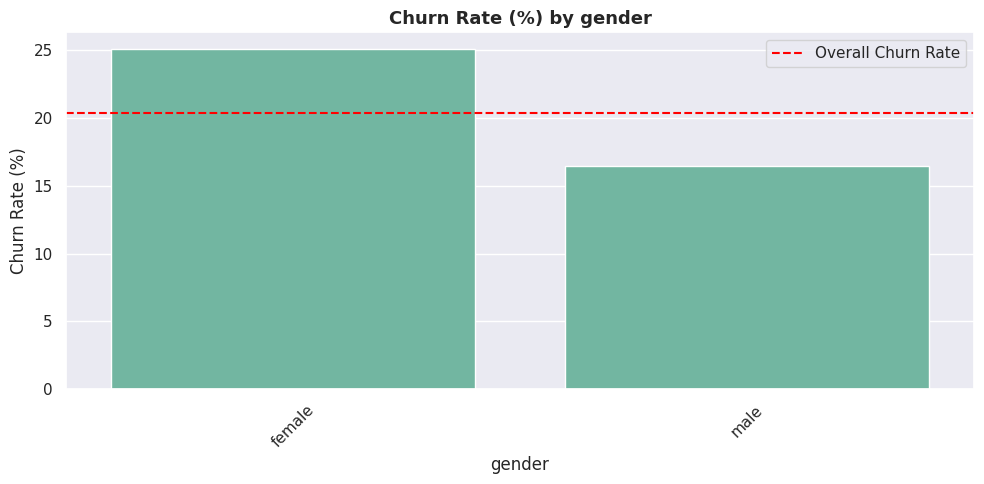

In [45]:
churn_rate_by_category(df_final, 'gender')

In [46]:
chi_2_test(df_final, 'gender', 'churn_label')

Chi²  p-value: 0.000000
  ✅ Reject H₀ — Significant association between "gender" and "churn_label".


In [47]:
pd.crosstab(df_final['gender'], df_final['churn_label'], margins=True)

churn_label,Churned,Retained,All
gender,,,
female,1139,3404,4543
male,898,4559,5457
All,2037,7963,10000


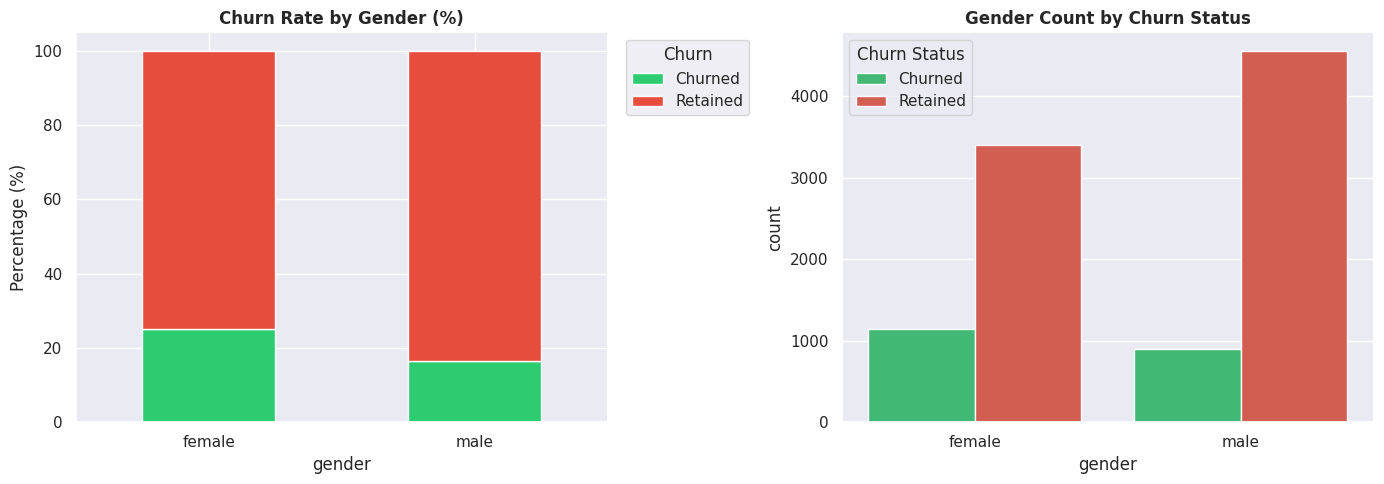

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct = pd.crosstab(df_final['gender'], df_final['churn_label'], normalize='index').mul(100).round(2)
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Rate by Gender (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Churn', bbox_to_anchor=(1.02, 1))
axes[0].tick_params(axis='x', rotation=0)
sns.countplot(data=df_final, x='gender', hue='churn_label', ax=axes[1],
              palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Gender Count by Churn Status', fontsize=12, fontweight='bold')
axes[1].legend(title='Churn Status')
plt.tight_layout()
plt.show()

**Observations**:
- **Female** customers churn significantly more (~25.07%) vs **Male** (~16.46%).
- Chi² test confirms a statistically significant association.


## Salary (Demographic sheet)

In [49]:
df_final['salary'].describe()

,salary
count,10000.000000
mean,100090.239881
std,57510.492818
min,11.580000
25%,51002.110000
50%,100193.915000
75%,149388.247500
max,199992.480000


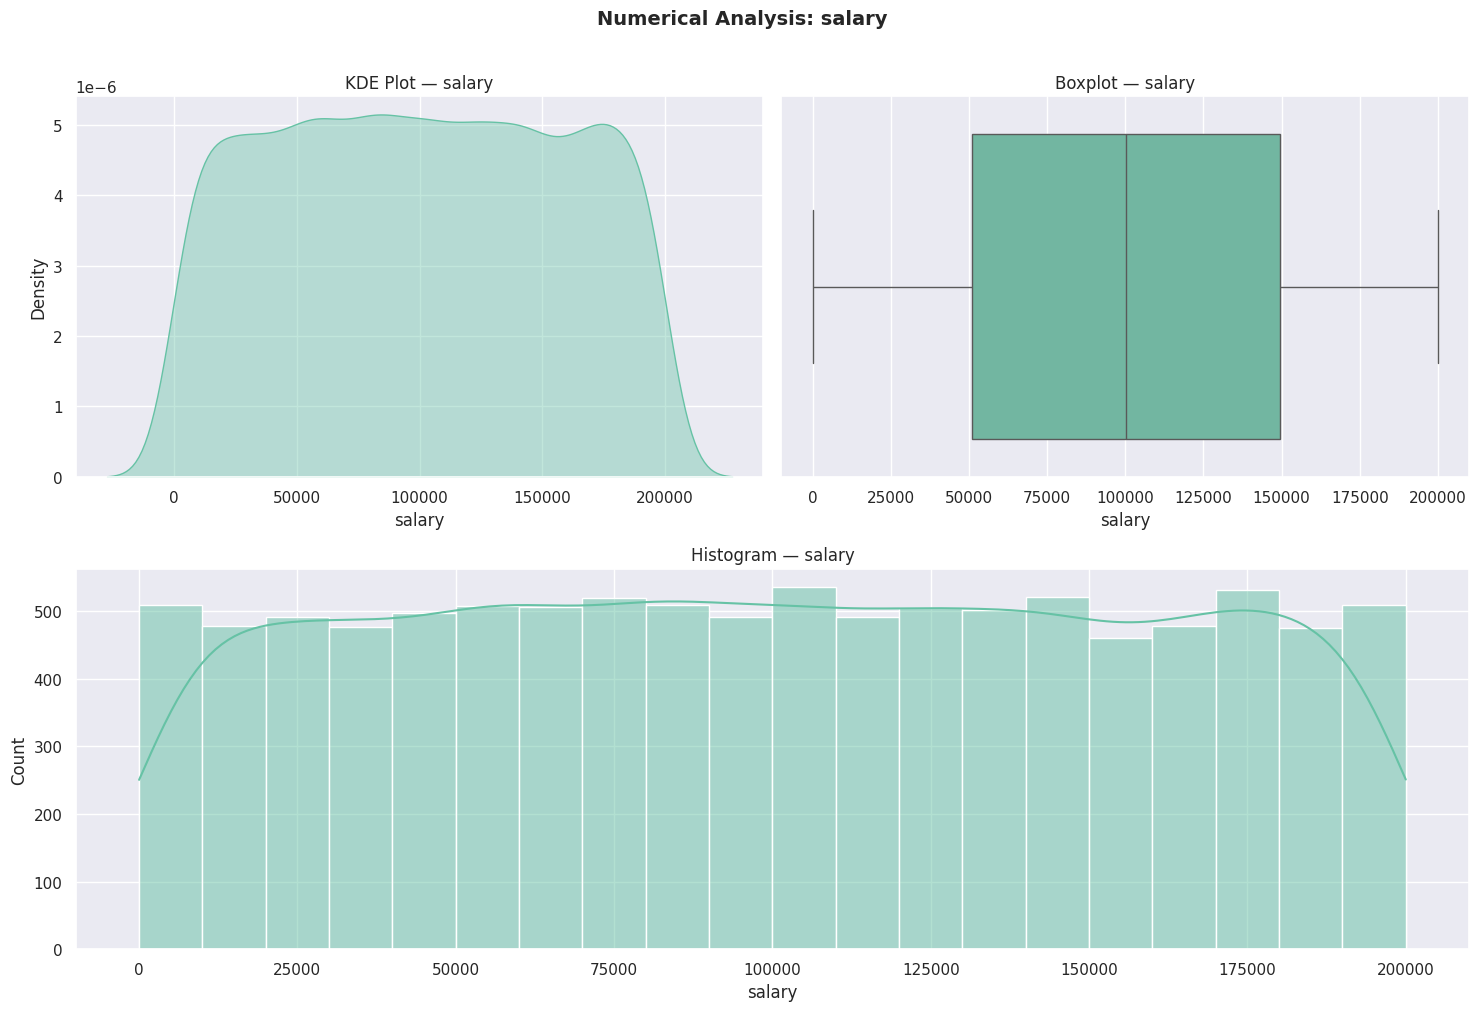

In [50]:
numerical_analysis(df_final, 'salary', bins=20)

In [51]:
test_for_normality(df_final, 'salary')

Jarque-Bera Test for Normality
  p-value: 0.000000
  ✅ Reject H₀ — Data is NOT normally distributed.


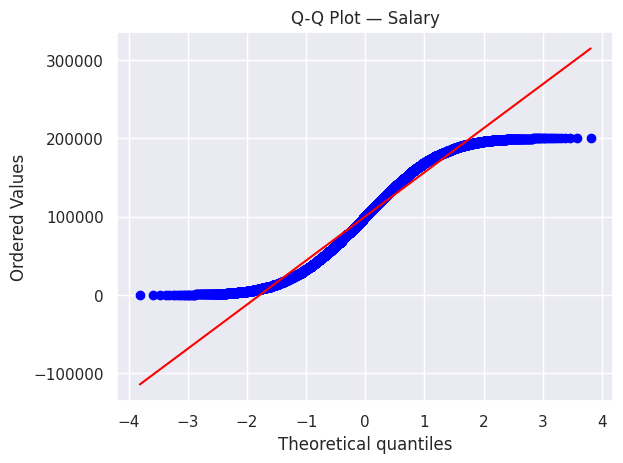

In [52]:
probplot(df_final['salary'], plot=plt)
plt.title('Q-Q Plot — Salary')
plt.show()

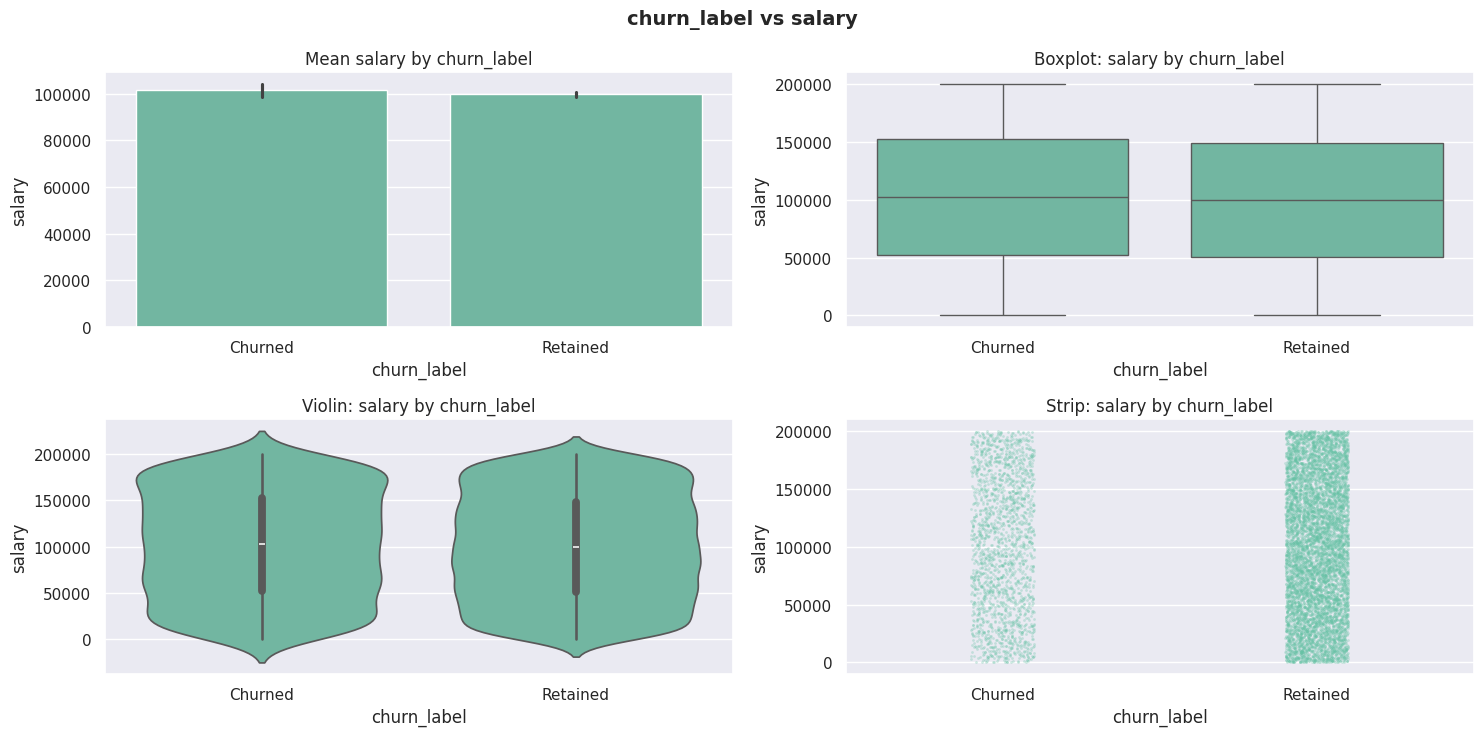

In [53]:
numerical_categorical_analysis(df_final, 'churn_label', 'salary')

In [54]:
anova_test(df_final, 'salary', 'churn_label')

ANOVA  F-stat: 1.4633  |  p-value: 0.226440
  ❌ Fail to reject H₀ — No significant relationship between "salary" and "churn_label".


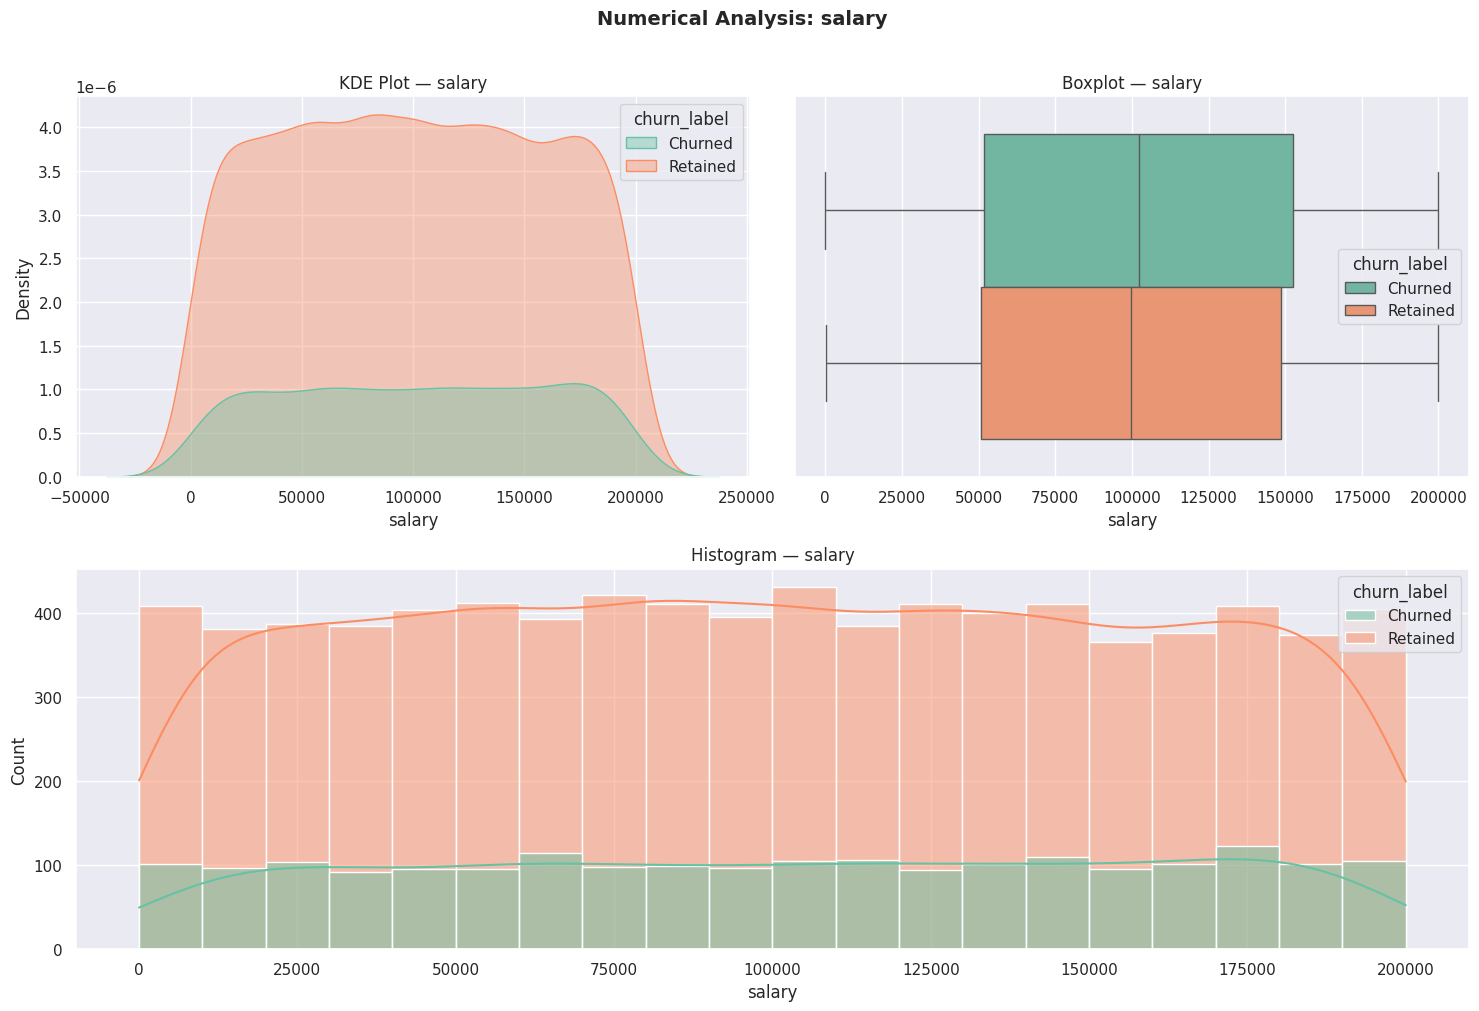

In [55]:
numerical_analysis(df_final, 'salary', cat_col='churn_label', bins=20)

,salary_bracket,churn_rate_%
3,very_high,21.47
2,high,20.23
0,low,19.93
1,medium,19.87


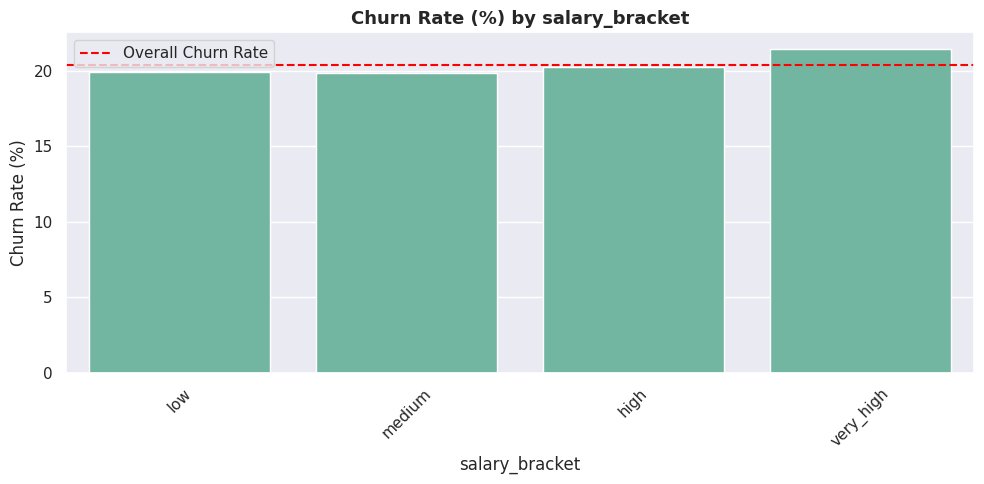

In [56]:
churn_rate_by_category(df_final, 'salary_bracket')

In [57]:
chi_2_test(df_final, 'salary_bracket', 'churn_label')

Chi²  p-value: 0.469551
  ❌ Fail to reject H₀ — No significant association between "salary_bracket" and "churn_label".


In [58]:
q25, q75 = np.percentile(df_final['salary'], [25, 75])
iqr = q75 - q25
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr
outliers = df_final.loc[(df_final['salary'] < lower_bound) | (df_final['salary'] > upper_bound)]
print(f'Salary bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'Outliers: {len(outliers)} ({len(outliers)/len(df_final)*100:.2f}%)')

Salary bounds: [-96577.10, 296967.45]
Outliers: 0 (0.00%)


## Geography (Location sheet)

,Count,Percentage
geography,,
france,1714,17.14%
uk,1703,17.03%
canada,1679,16.79%
usa,1669,16.69%
germany,1626,16.26%
spain,1609,16.09%


**************************************************
Unique categories in "geography": ['france', 'usa', 'uk', 'germany', 'canada', 'spain']
**************************************************
Number of categories: 6


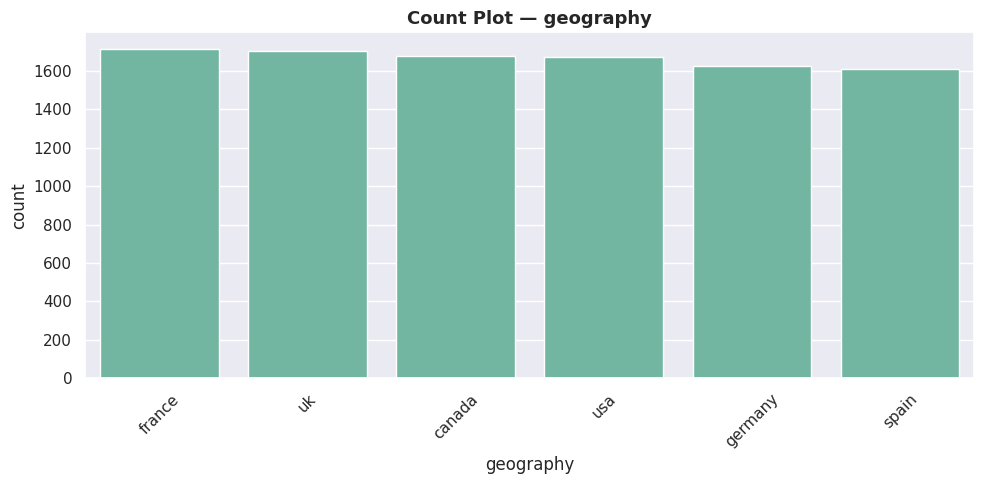

In [59]:
categorical_analysis(df_final, 'geography')

,geography,churn_rate_%
3,spain,21.13
5,usa,20.91
4,uk,20.67
1,france,20.13
0,canada,20.01
2,germany,19.37


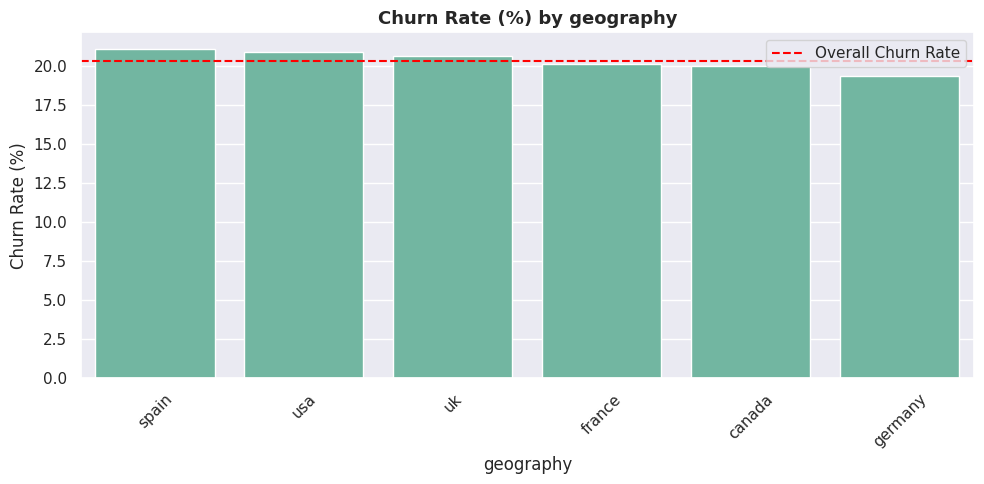

In [60]:
churn_rate_by_category(df_final, 'geography')

In [61]:
chi_2_test(df_final, 'geography', 'churn_label')

Chi²  p-value: 0.826436
  ❌ Fail to reject H₀ — No significant association between "geography" and "churn_label".


In [62]:
pd.crosstab(df_final['geography'], df_final['churn_label'], margins=True)

churn_label,Churned,Retained,All
geography,,,
canada,336,1343,1679
france,345,1369,1714
germany,315,1311,1626
spain,340,1269,1609
uk,352,1351,1703
usa,349,1320,1669
All,2037,7963,10000


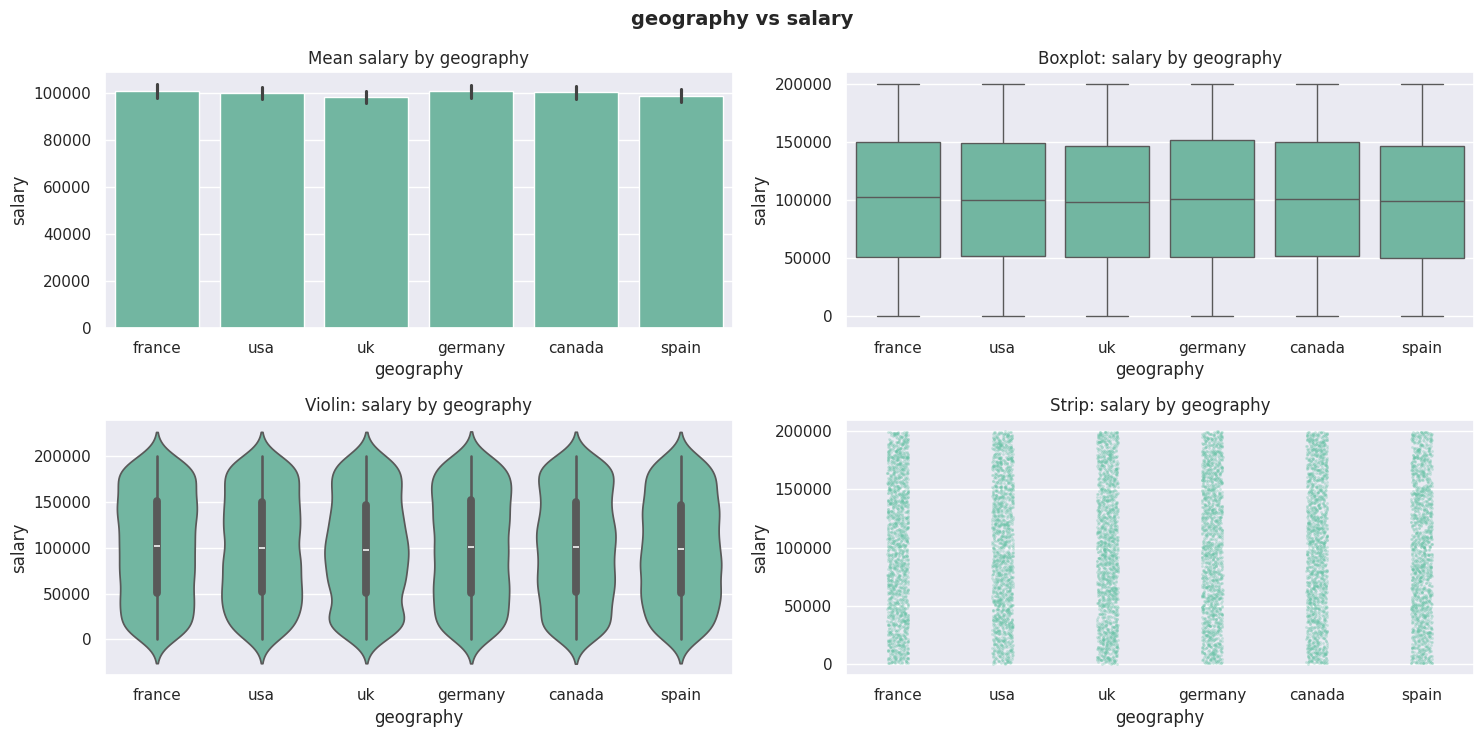

In [63]:
numerical_categorical_analysis(df_final, 'geography', 'salary')

In [64]:
anova_test(df_final, 'salary', 'geography')

ANOVA  F-stat: 0.5181  |  p-value: 0.762813
  ❌ Fail to reject H₀ — No significant relationship between "salary" and "geography".


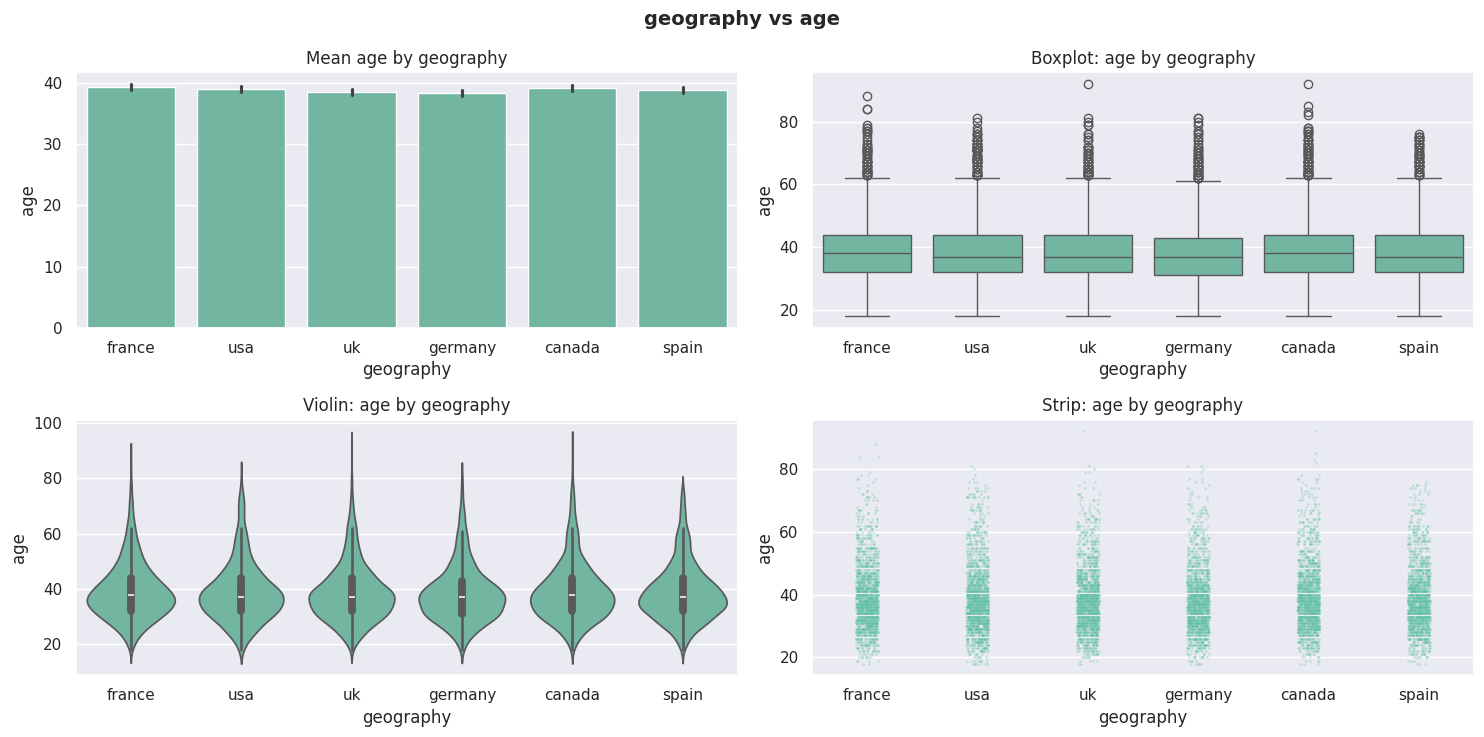

In [65]:
numerical_categorical_analysis(df_final, 'geography', 'age')

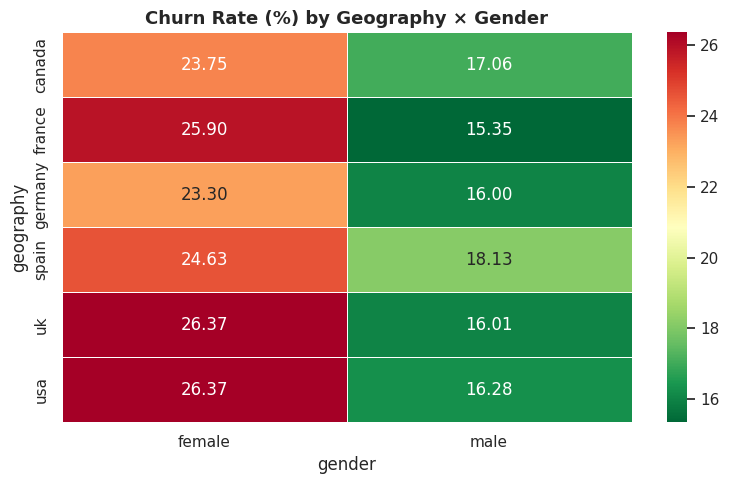

In [66]:
pivot = df_final.pivot_table(index='geography', columns='gender',
                              values='churned', aggfunc='mean').mul(100).round(2)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Churn Rate (%) by Geography × Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Tenure (Account sheet)

In [67]:
df_final['tenure'].dtype

dtype('int64')

In [68]:
df_final['tenure'].describe()

,tenure
count,10000.000000
mean,5.012800
std,2.892174
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


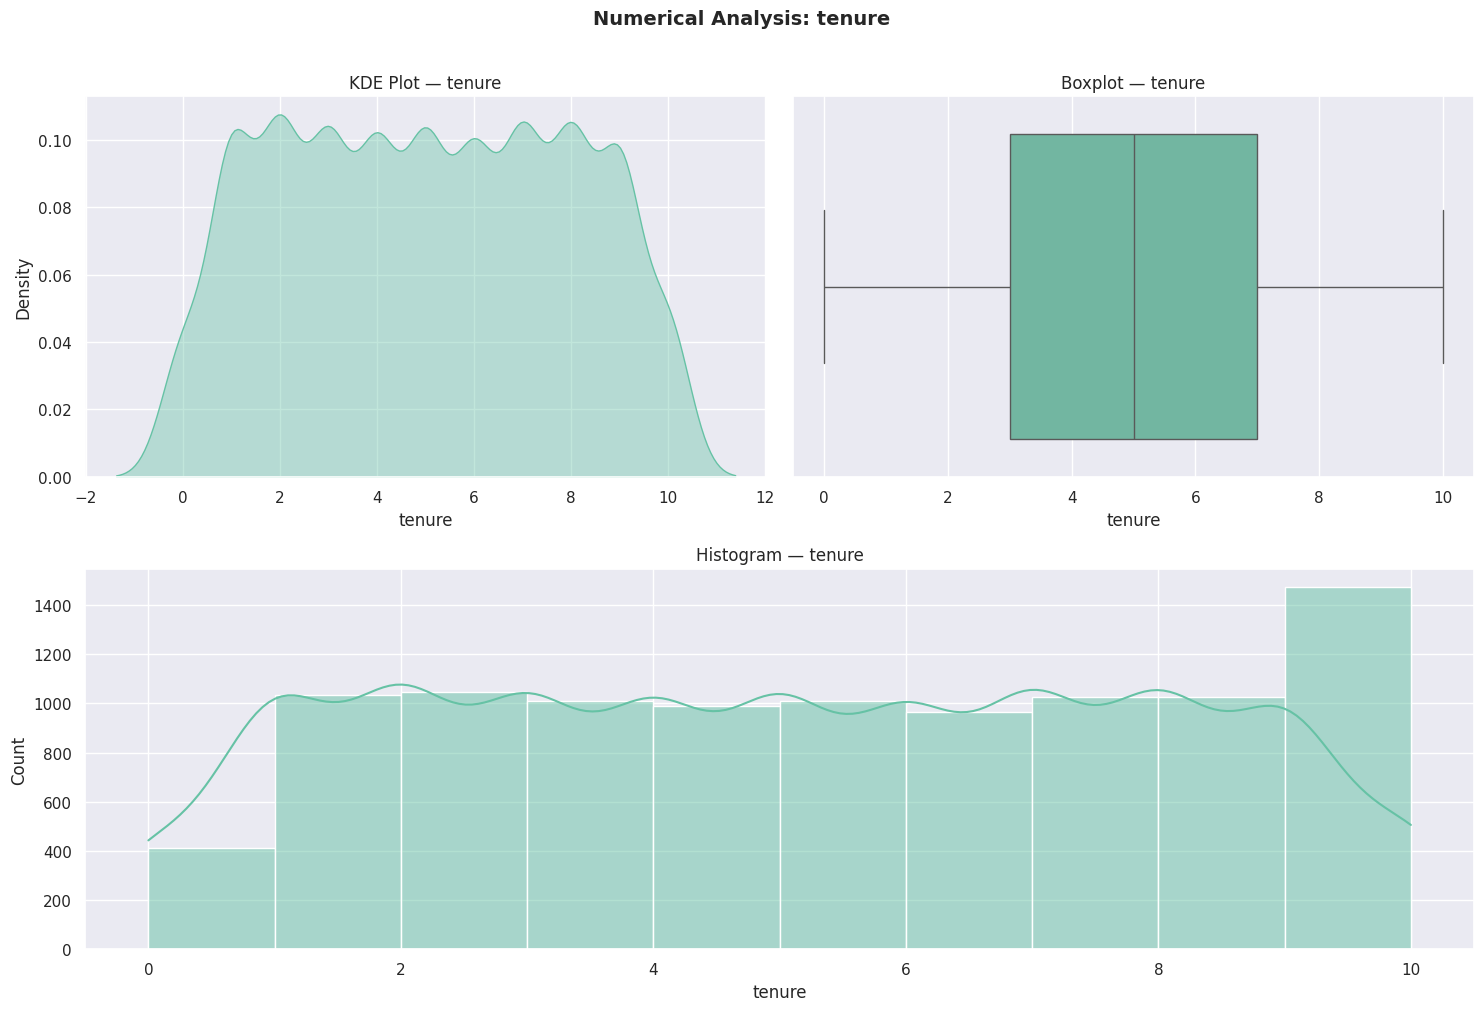

In [69]:
numerical_analysis(df_final, 'tenure', bins=10)

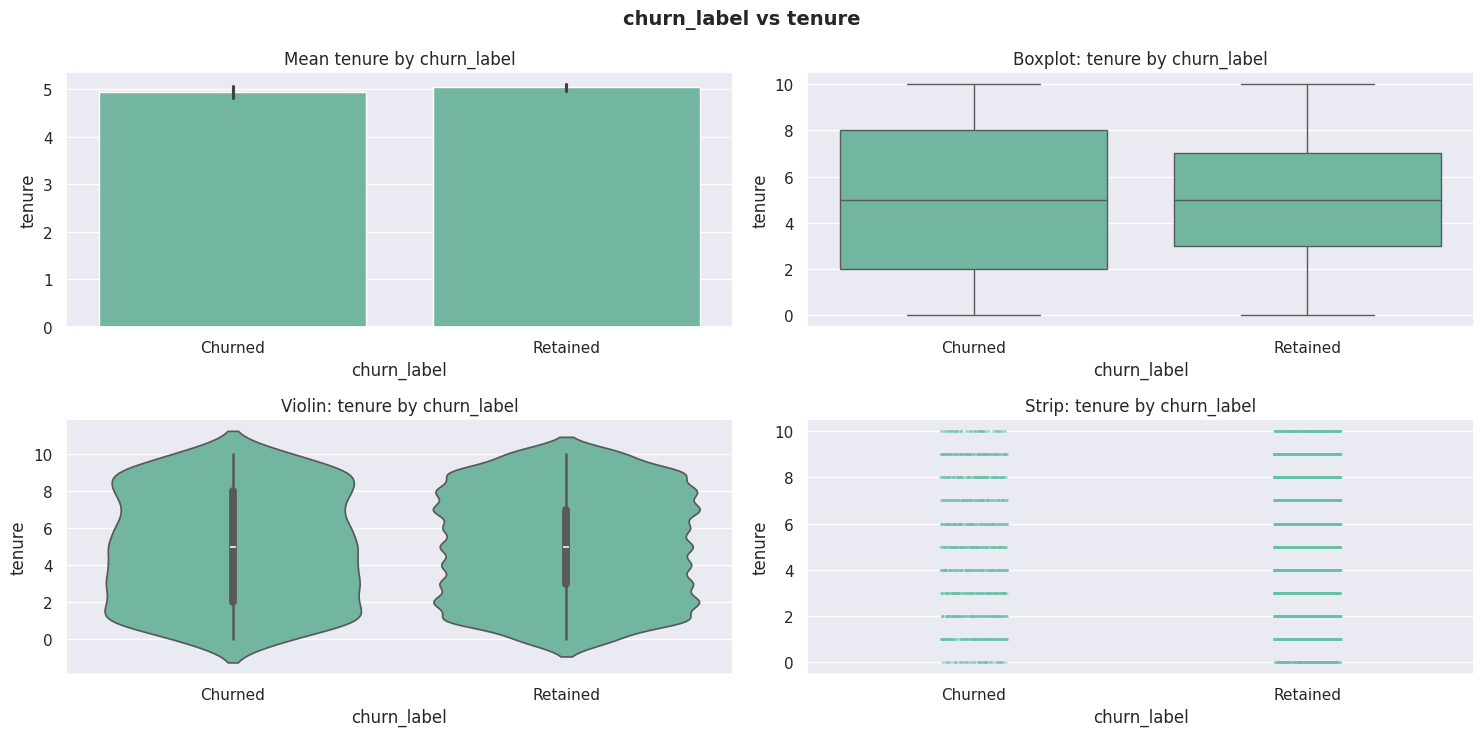

In [70]:
numerical_categorical_analysis(df_final, 'churn_label', 'tenure')

In [71]:
anova_test(df_final, 'tenure', 'churn_label')

ANOVA  F-stat: 1.9602  |  p-value: 0.161527
  ❌ Fail to reject H₀ — No significant relationship between "tenure" and "churn_label".


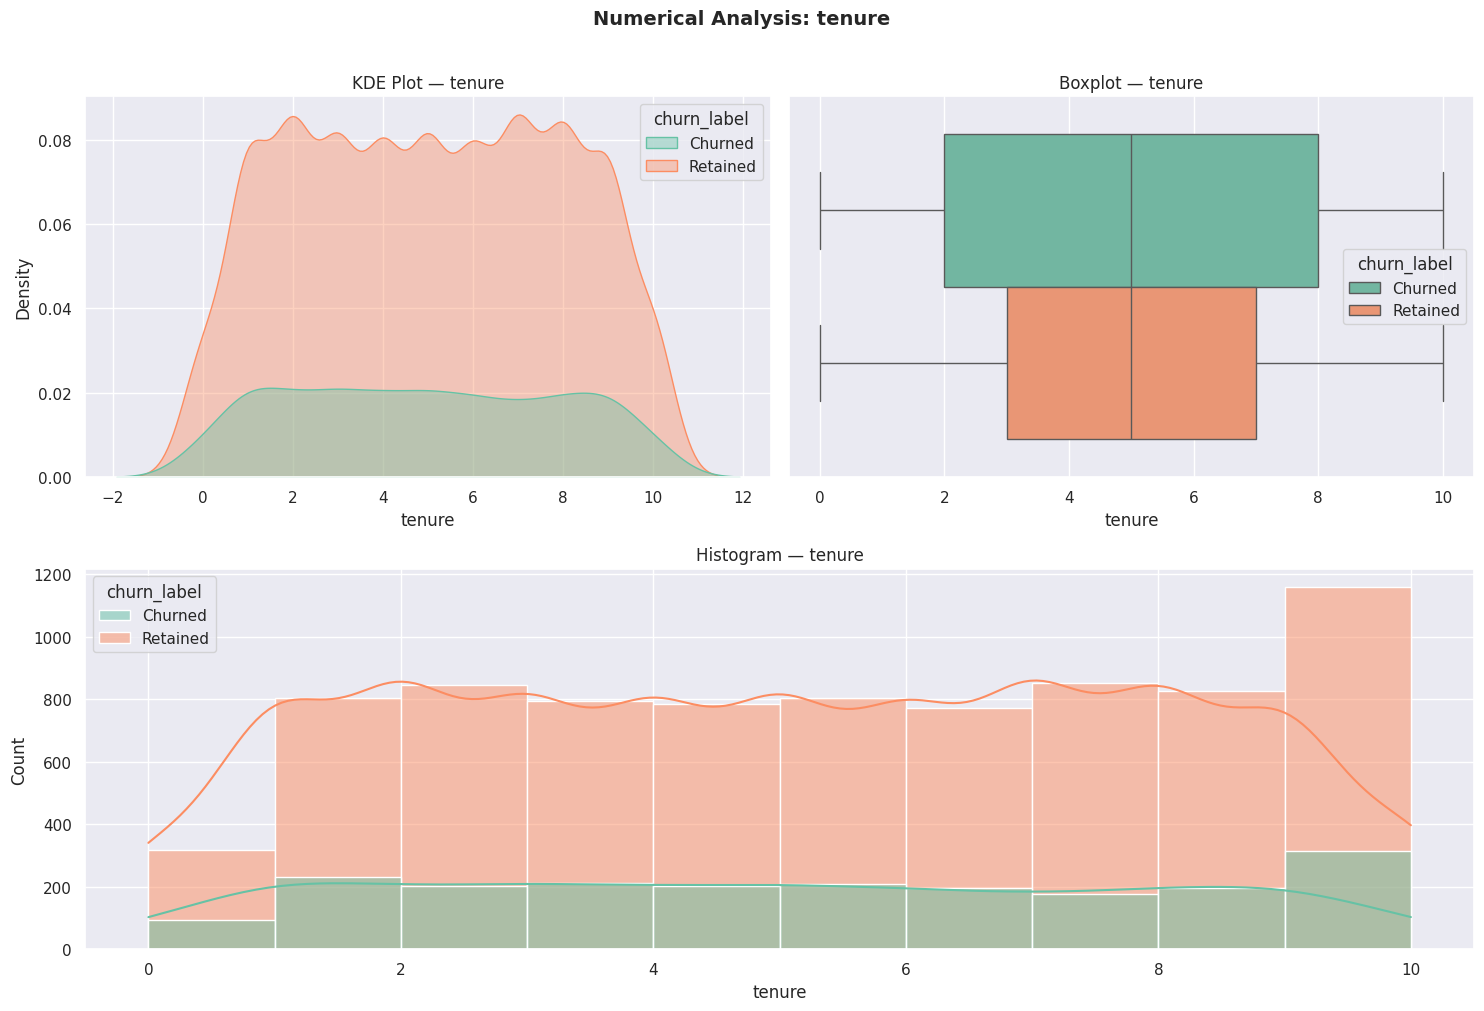

In [72]:
numerical_analysis(df_final, 'tenure', cat_col='churn_label', bins=10)

,Count,Percentage
tenure_group,,
mid (3-5),3010,30.1%
veteran (8-10),2499,24.99%
new (0-2),2496,24.96%
senior (6-7),1995,19.95%


**************************************************
Unique categories in "tenure_group": ['new (0-2)', 'veteran (8-10)', 'senior (6-7)', 'mid (3-5)']
**************************************************
Number of categories: 4


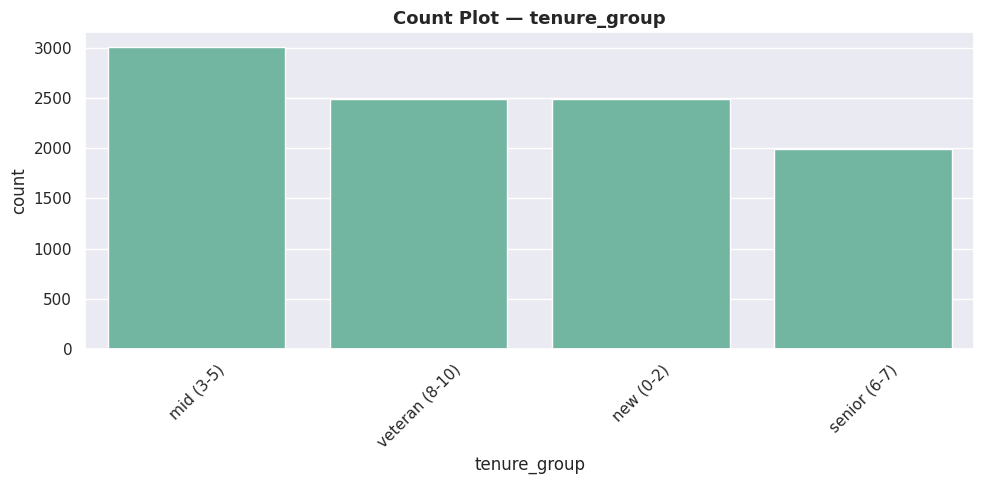

In [73]:
categorical_analysis(df_final, 'tenure_group')

,tenure_group,churn_rate_%
0,new (0-2),21.15
1,mid (3-5),20.76
3,veteran (8-10),20.45
2,senior (6-7),18.70


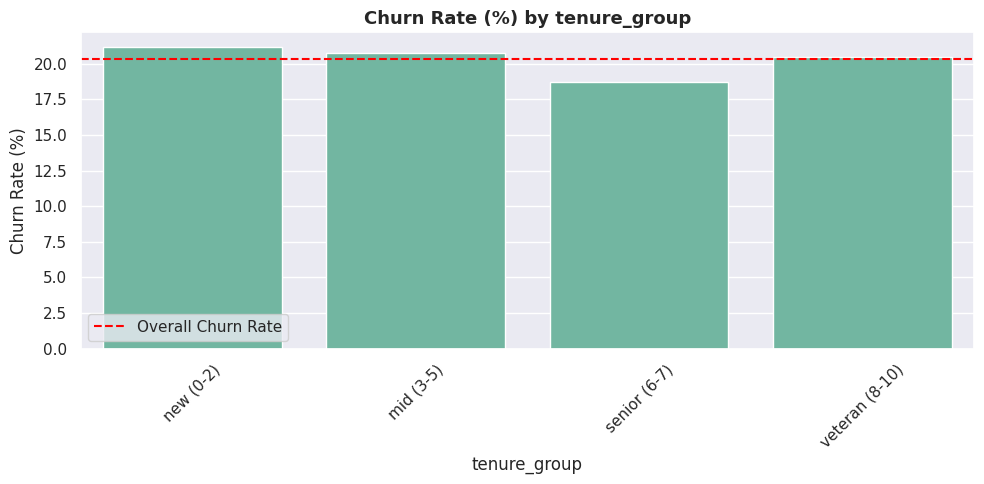

In [74]:
churn_rate_by_category(df_final, 'tenure_group')

In [75]:
chi_2_test(df_final, 'tenure_group', 'churn_label')

Chi²  p-value: 0.196237
  ❌ Fail to reject H₀ — No significant association between "tenure_group" and "churn_label".


## Balance (Account sheet)

In [76]:
null_count = df_final['balance'].isnull().sum()
print(f'Balance nulls: {null_count} ({null_count/len(df_final)*100:.2f}%)')
print('These rows represent zero-balance / no recorded balance accounts.')

Balance nulls: 3617 (36.17%)
These rows represent zero-balance / no recorded balance accounts.


,has_balance,churn_rate_%
1,1,24.08
0,0,13.82


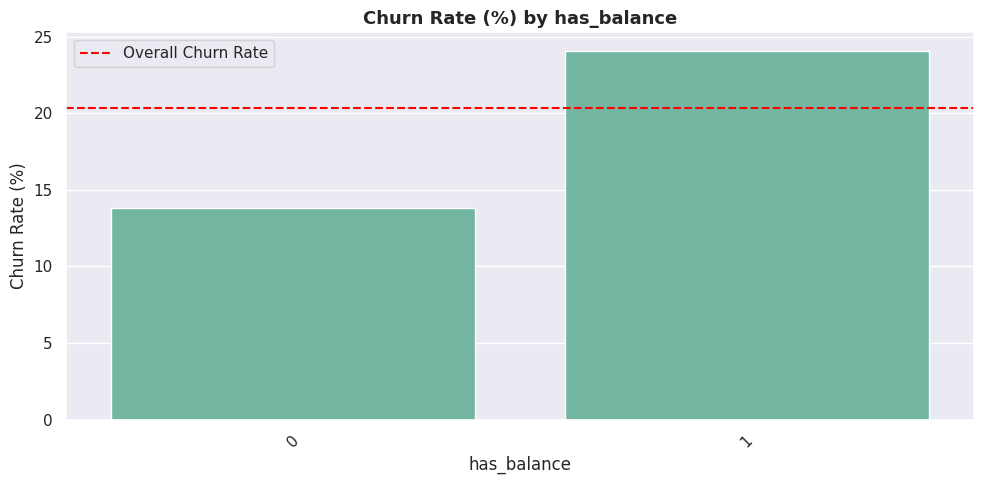

In [77]:
churn_rate_by_category(df_final, 'has_balance')

In [78]:
chi_2_test(df_final, 'has_balance', 'churned')

Chi²  p-value: 0.000000
  ✅ Reject H₀ — Significant association between "has_balance" and "churned".


In [79]:
df_final['balance'].describe()

,balance
count,6383.000000
mean,119827.493793
std,30095.056462
min,3768.690000
25%,100181.975000
50%,119839.690000
75%,139512.290000
max,250898.090000


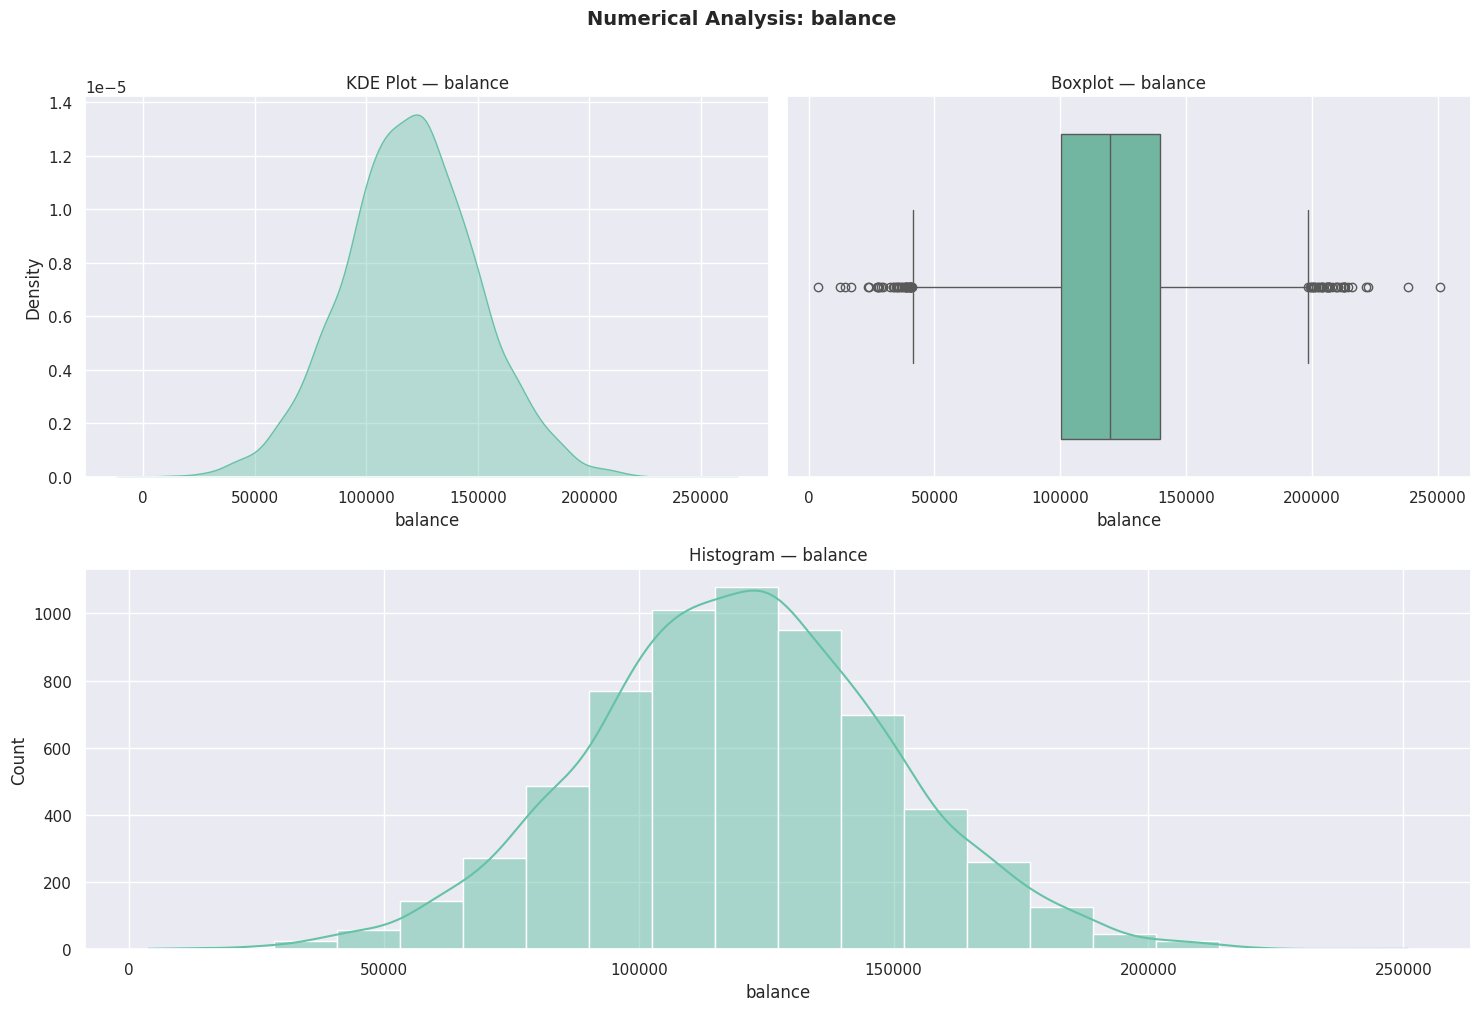

In [80]:
numerical_analysis(df_final.dropna(subset=['balance']), 'balance', bins=20)

In [81]:
test_for_normality(df_final.dropna(subset=['balance']), 'balance')

Jarque-Bera Test for Normality
  p-value: 0.004164
  ✅ Reject H₀ — Data is NOT normally distributed.


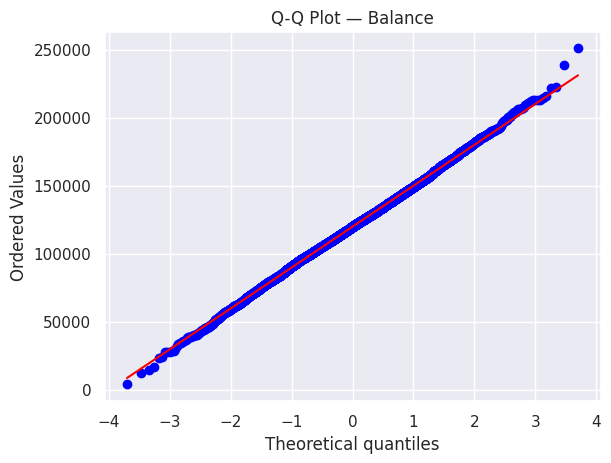

In [82]:
probplot(df_final['balance'].dropna(), plot=plt)
plt.title('Q-Q Plot — Balance')
plt.show()

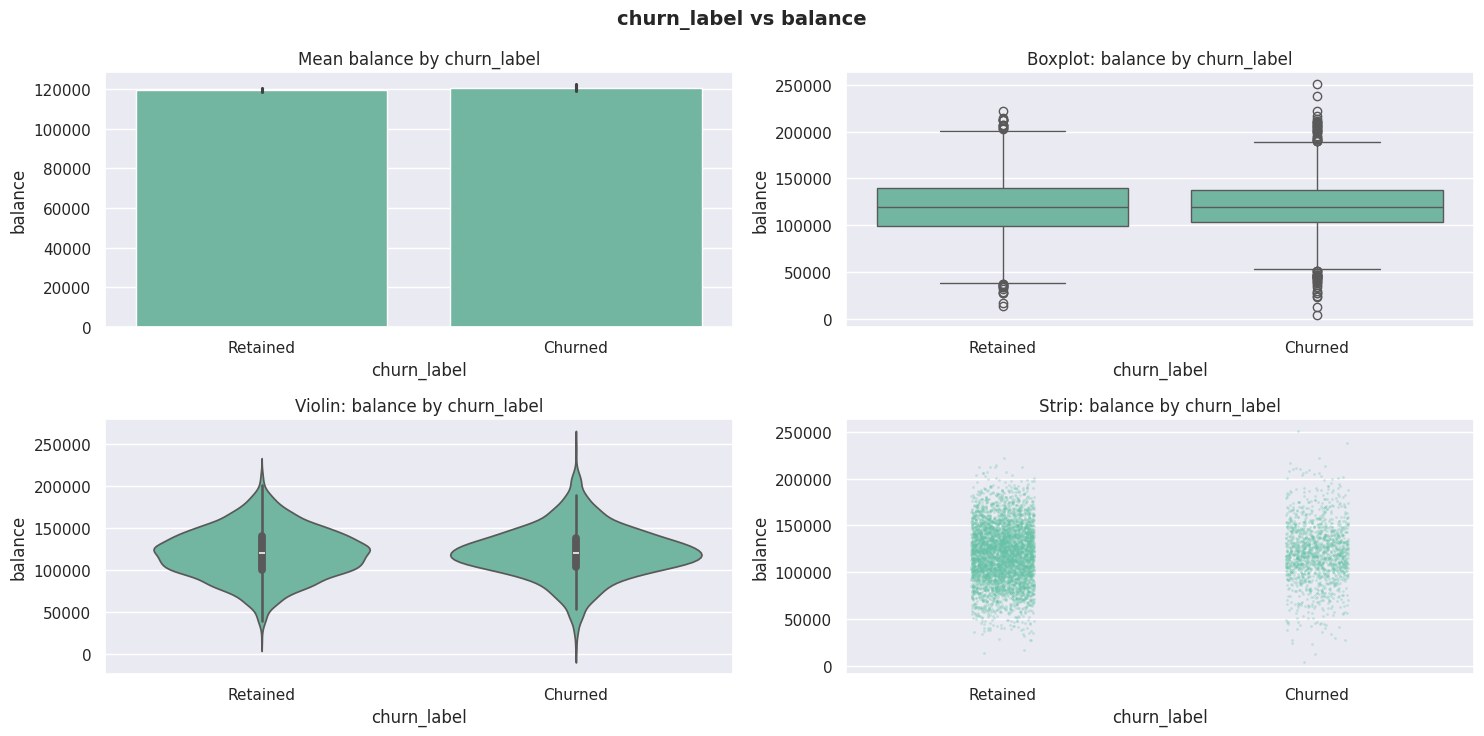

In [83]:
numerical_categorical_analysis(
    df_final.dropna(subset=['balance']), 'churn_label', 'balance'
)

In [84]:
anova_test(df_final.dropna(subset=['balance']), 'balance', 'churn_label')

ANOVA  F-stat: 1.8900  |  p-value: 0.169247
  ❌ Fail to reject H₀ — No significant relationship between "balance" and "churn_label".


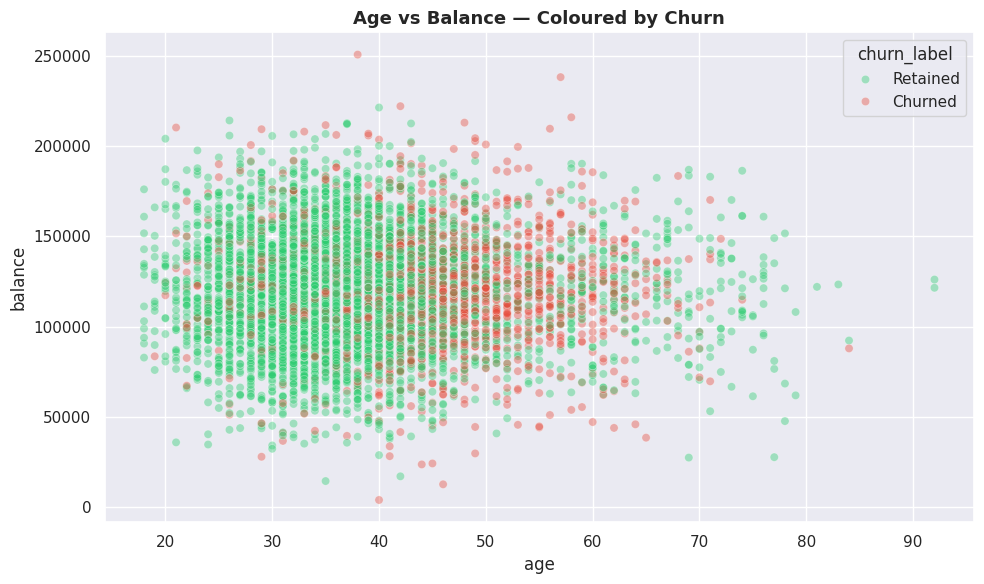

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_final.dropna(subset=['balance']),
    x='age', y='balance', hue='churn_label', alpha=0.4, ax=ax,
    palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'}
)
ax.set_title('Age vs Balance — Coloured by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Number of Products (Account sheet)

In [86]:
df_final['num_products'].dtype

dtype('int64')

,Count,Percentage
num_products,,
1,5084,50.84%
2,4590,45.9%
3,266,2.66%
4,60,0.6%


**************************************************
Unique categories in "num_products": [1, 3, 2, 4]
**************************************************
Number of categories: 4


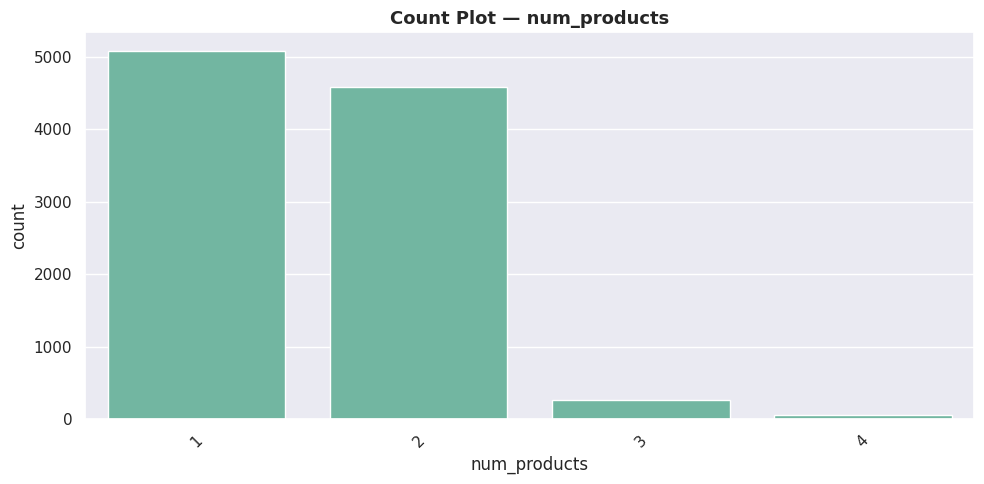

In [87]:
categorical_analysis(df_final, 'num_products')

,num_products,churn_rate_%
3,4,100.00
2,3,82.71
0,1,27.71
1,2,7.58


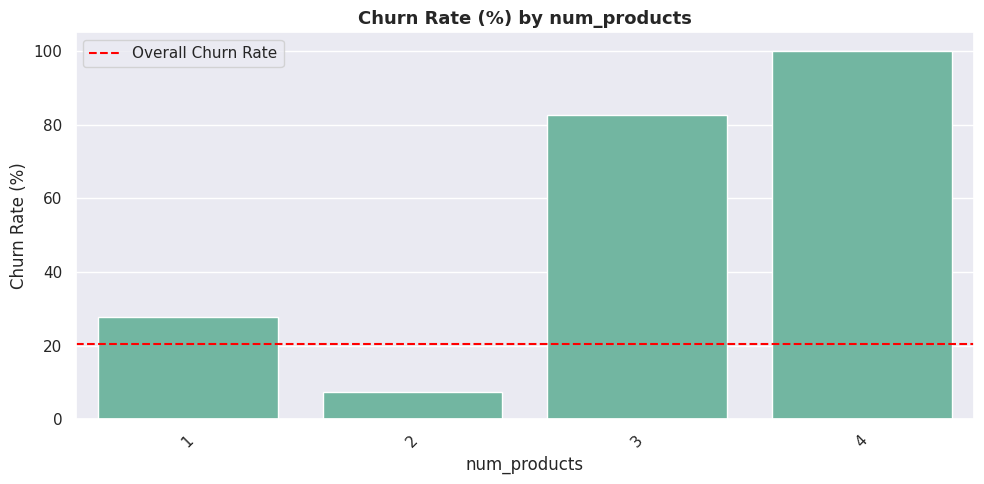

In [88]:
churn_rate_by_category(df_final, 'num_products')

In [89]:
chi_2_test(df_final, 'num_products', 'churn_label')

Chi²  p-value: 0.000000
  ✅ Reject H₀ — Significant association between "num_products" and "churn_label".


In [90]:
pd.crosstab(df_final['num_products'], df_final['churn_label'], margins=True)

churn_label,Churned,Retained,All
num_products,,,
1,1409,3675,5084
2,348,4242,4590
3,220,46,266
4,60,0,60
All,2037,7963,10000


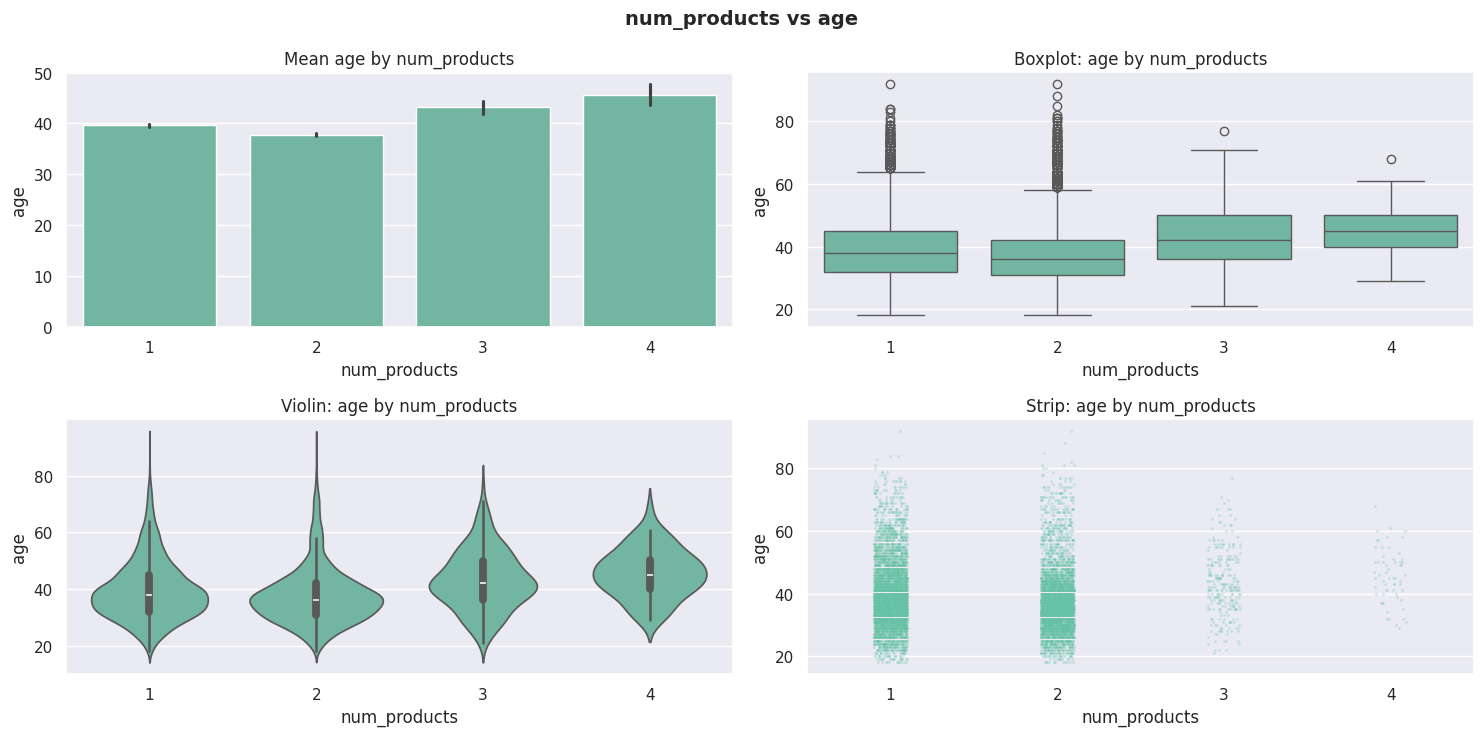

In [91]:
numerical_categorical_analysis(df_final, 'num_products', 'age')

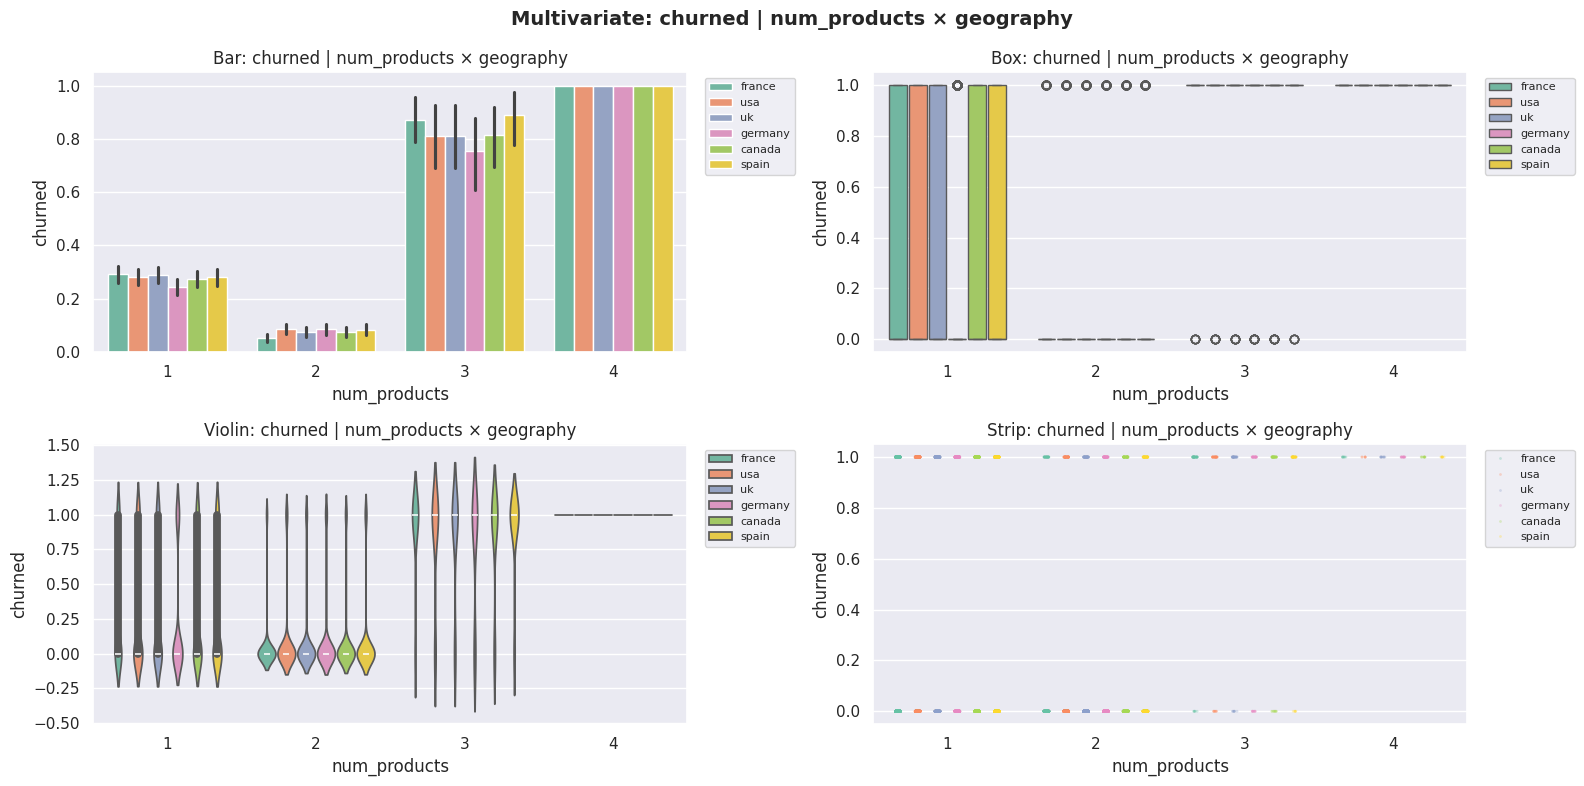

In [92]:
multivariate_analysis(df_final, 'churned', 'num_products', 'geography')

**Observations**:
- Customers with **3 or 4 products** have extremely high churn rates (82% and 100%).
- Customers with **2 products** have the lowest churn (~7.58%).
- This is a **very strong and non-linear predictor** of churn.


## Has Credit Card (Account sheet)

,Count,Percentage
has_credit_card_label,,
Has Card,7055,70.55%
No Card,2945,29.45%


**************************************************
Unique categories in "has_credit_card_label": ['Has Card', 'No Card']
**************************************************
Number of categories: 2


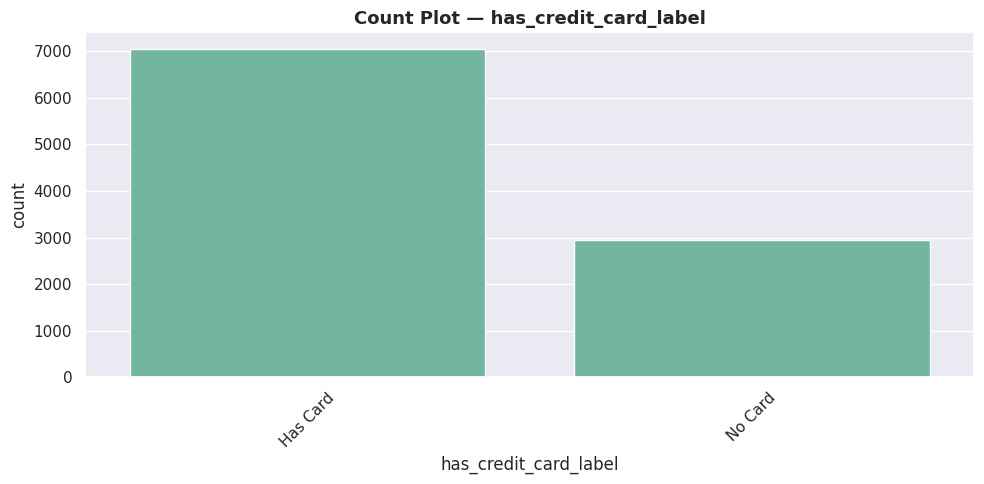

In [93]:
categorical_analysis(df_final, 'has_credit_card_label')

,has_credit_card_label,churn_rate_%
1,No Card,20.81
0,Has Card,20.18


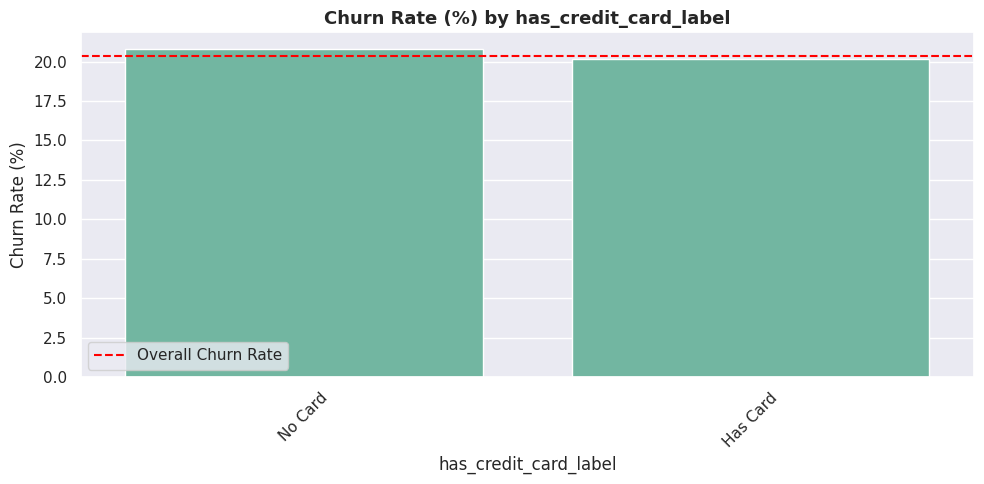

In [94]:
churn_rate_by_category(df_final, 'has_credit_card_label')

In [95]:
chi_2_test(df_final, 'has_credit_card_label', 'churn_label')

Chi²  p-value: 0.492372
  ❌ Fail to reject H₀ — No significant association between "has_credit_card_label" and "churn_label".


In [96]:
chi_2_test(df_final, 'has_credit_card_label', 'geography')

Chi²  p-value: 0.884336
  ❌ Fail to reject H₀ — No significant association between "has_credit_card_label" and "geography".


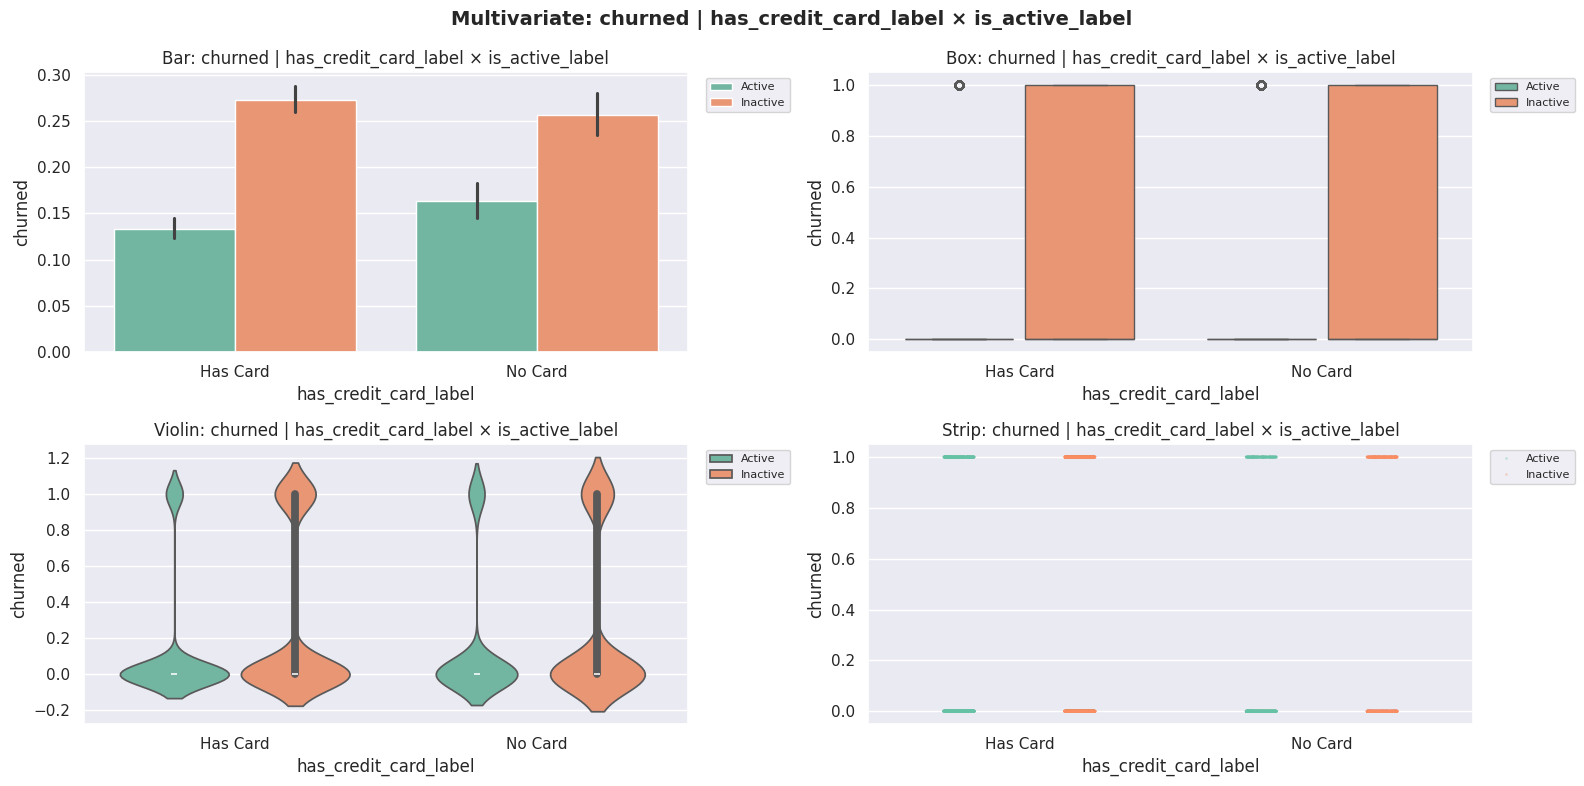

In [97]:
multivariate_analysis(df_final, 'churned', 'has_credit_card_label', 'is_active_label')

## Is Active (Account sheet)

,Count,Percentage
is_active_label,,
Active,5151,51.51%
Inactive,4849,48.49%


**************************************************
Unique categories in "is_active_label": ['Active', 'Inactive']
**************************************************
Number of categories: 2


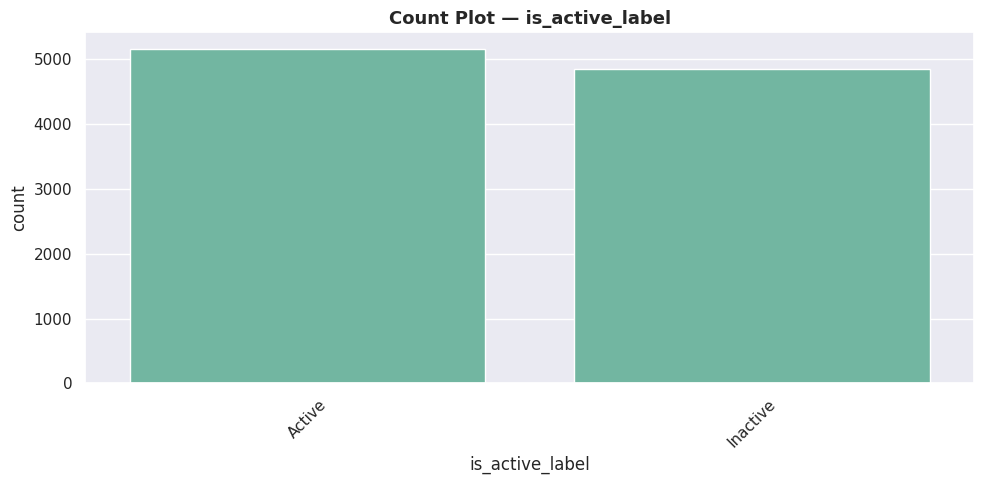

In [98]:
categorical_analysis(df_final, 'is_active_label')

,is_active_label,churn_rate_%
1,Inactive,26.85
0,Active,14.27


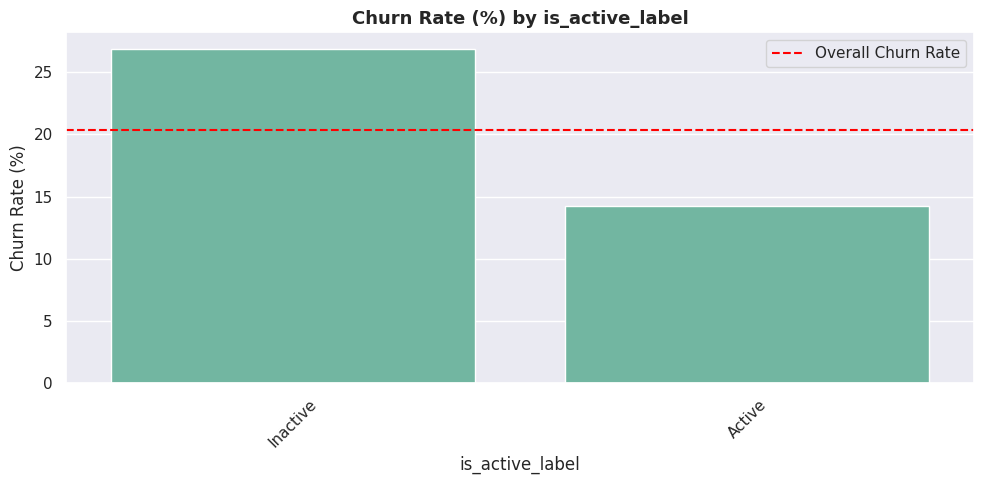

In [99]:
churn_rate_by_category(df_final, 'is_active_label')

In [100]:
chi_2_test(df_final, 'is_active_label', 'churn_label')

Chi²  p-value: 0.000000
  ✅ Reject H₀ — Significant association between "is_active_label" and "churn_label".


In [101]:
pd.crosstab(df_final['is_active_label'], df_final['churn_label'], margins=True)

churn_label,Churned,Retained,All
is_active_label,,,
Active,735,4416,5151
Inactive,1302,3547,4849
All,2037,7963,10000


In [102]:
chi_2_test(df_final, 'is_active_label', 'geography')

Chi²  p-value: 0.970202
  ❌ Fail to reject H₀ — No significant association between "is_active_label" and "geography".


In [103]:
chi_2_test(df_final, 'is_active_label', 'num_products')

Chi²  p-value: 0.000645
  ✅ Reject H₀ — Significant association between "is_active_label" and "num_products".


In [104]:
df_final.pivot_table(
    index='is_active_label', columns='num_products',
    values='churned', aggfunc='mean'
).mul(100).round(2)

num_products,1,2,3,4
is_active_label,,,,
Active,18.92,5.56,75.22,100.0
Inactive,36.65,9.89,88.24,100.0


**Observations**:
- **Inactive** customers churn at ~26.85% vs Active at ~14.27%.
- Nearly double the risk — strong predictive signal.


# Multivariate / Cross-Sheet Analysis

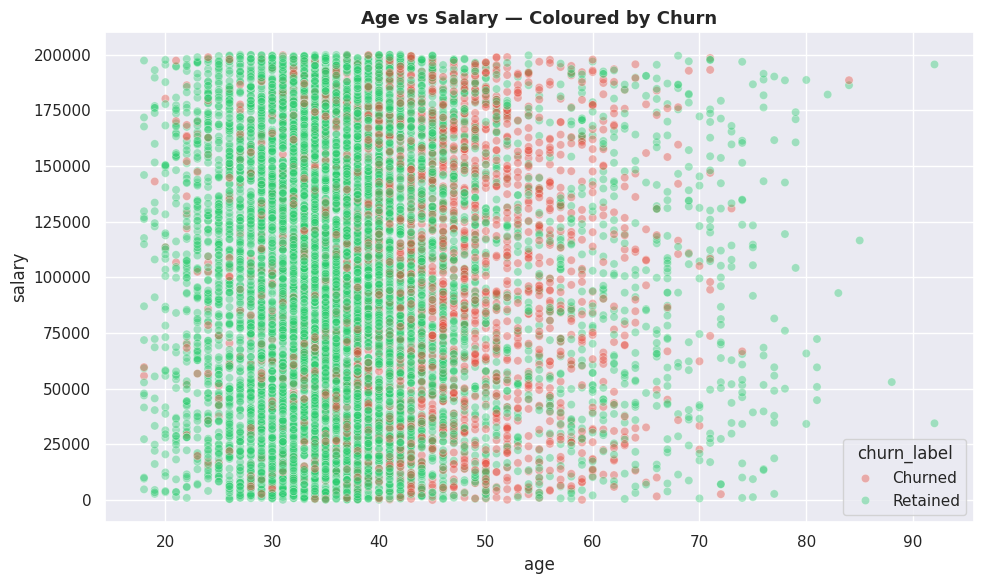

In [105]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_final, x='age', y='salary', hue='churn_label', alpha=0.4, ax=ax,
    palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'}
)
ax.set_title('Age vs Salary — Coloured by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

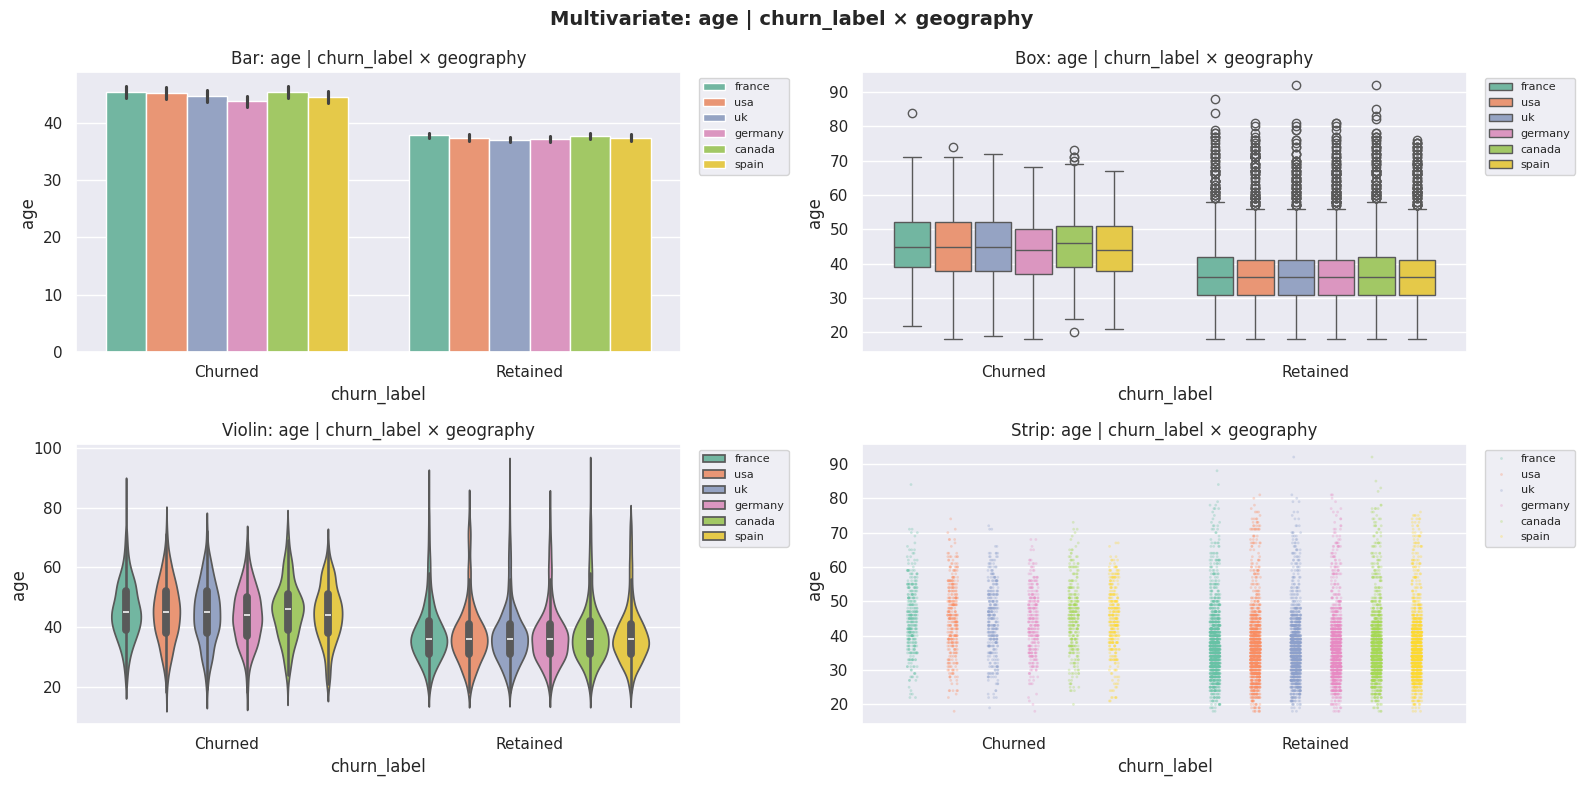

In [106]:
multivariate_analysis(df_final, 'age', 'churn_label', 'geography')

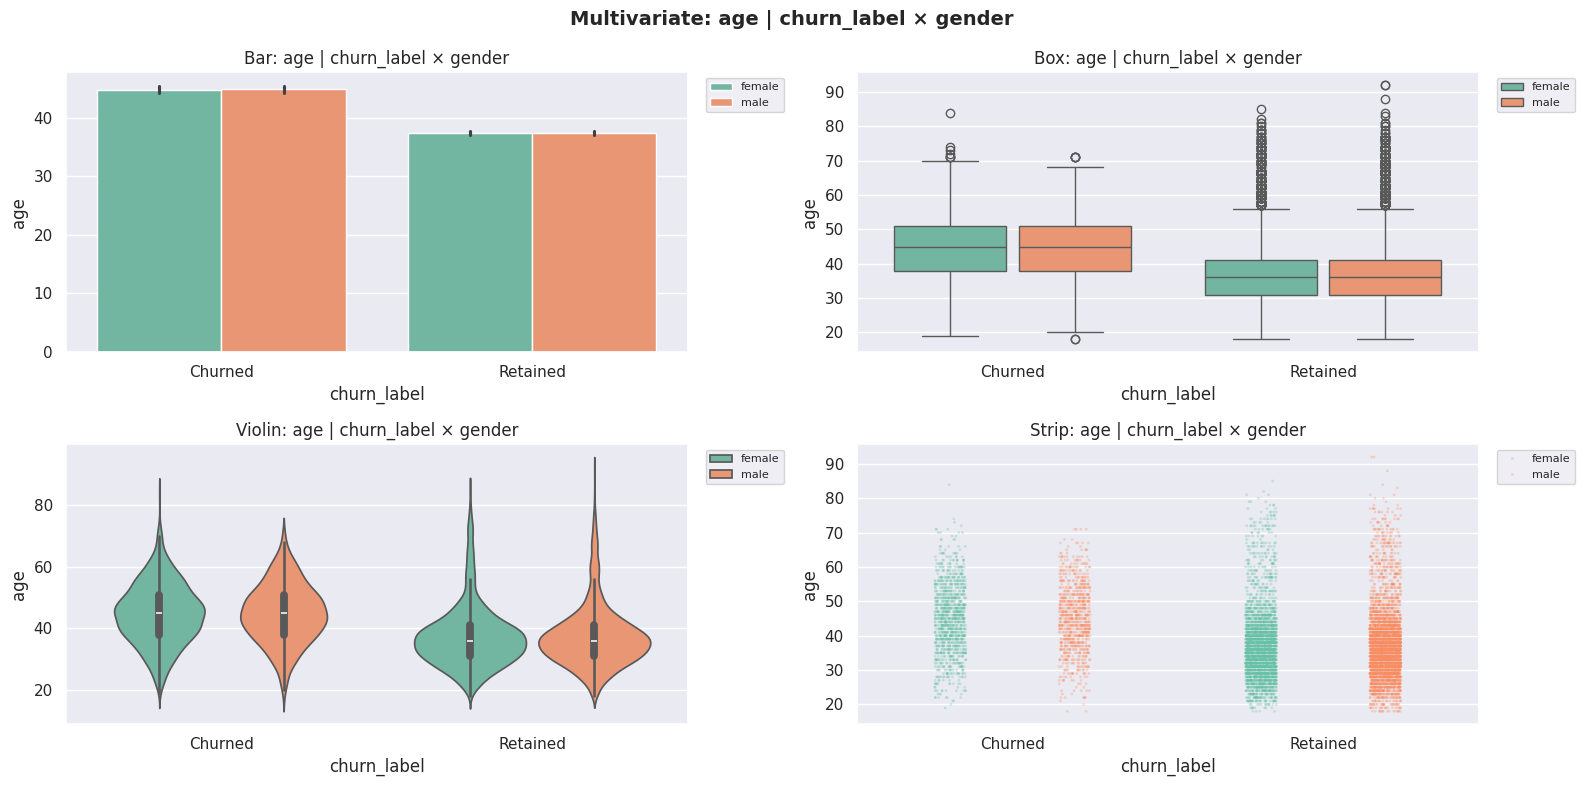

In [107]:
multivariate_analysis(df_final, 'age', 'churn_label', 'gender')

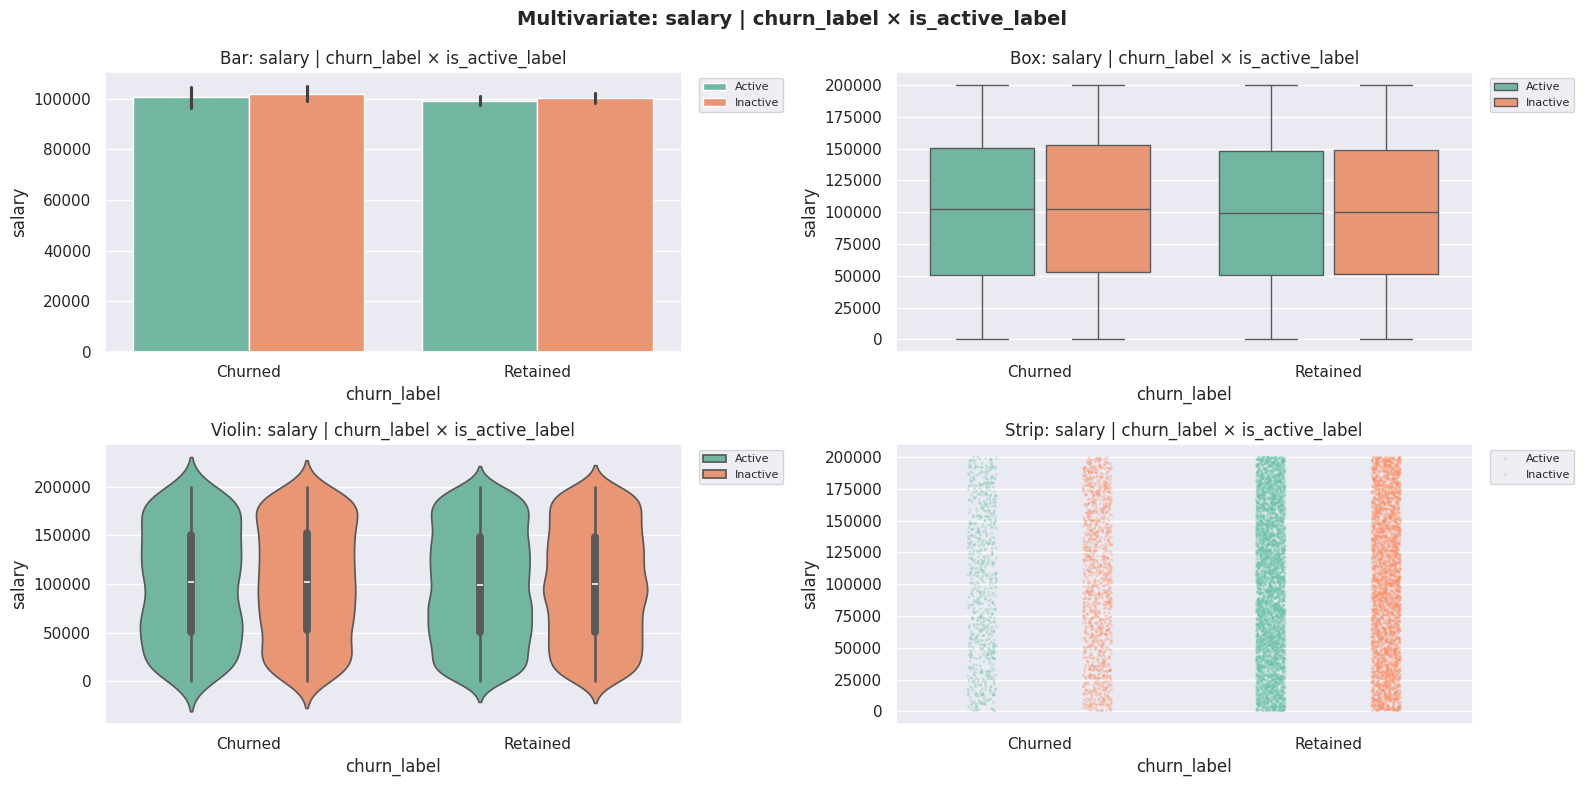

In [108]:
multivariate_analysis(df_final, 'salary', 'churn_label', 'is_active_label')

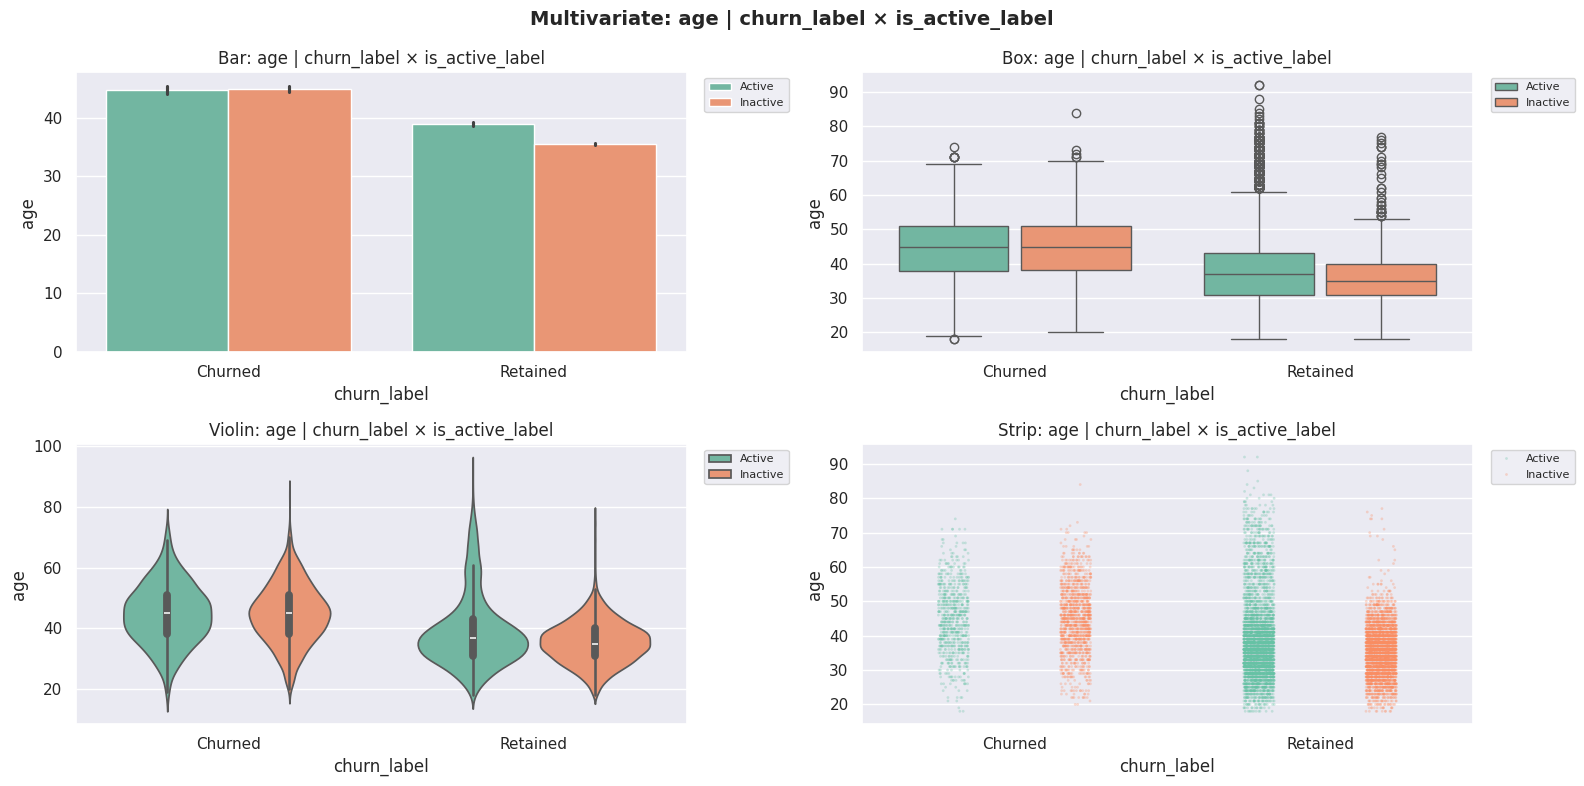

In [109]:
multivariate_analysis(df_final, 'age', 'churn_label', 'is_active_label')

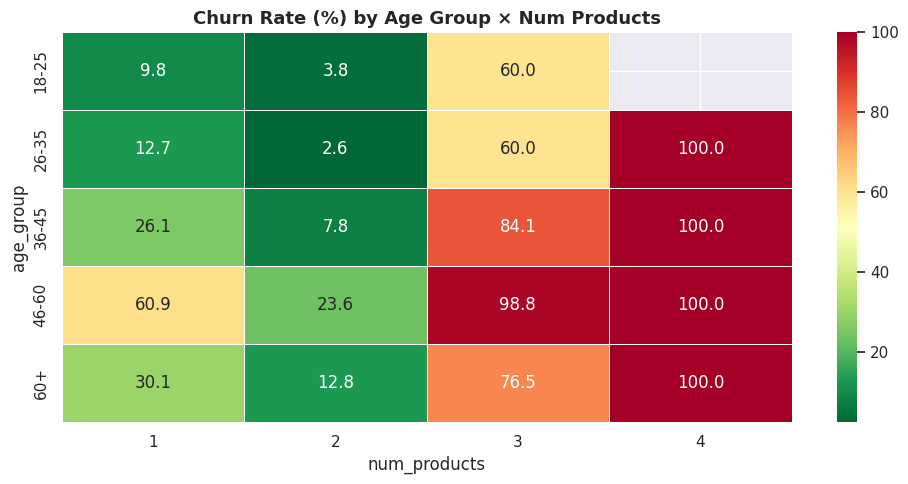

In [110]:
pivot_ap = df_final.pivot_table(
    index='age_group', columns='num_products',
    values='churned', aggfunc='mean'
).mul(100).round(2)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_ap, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Churn Rate (%) by Age Group × Num Products', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

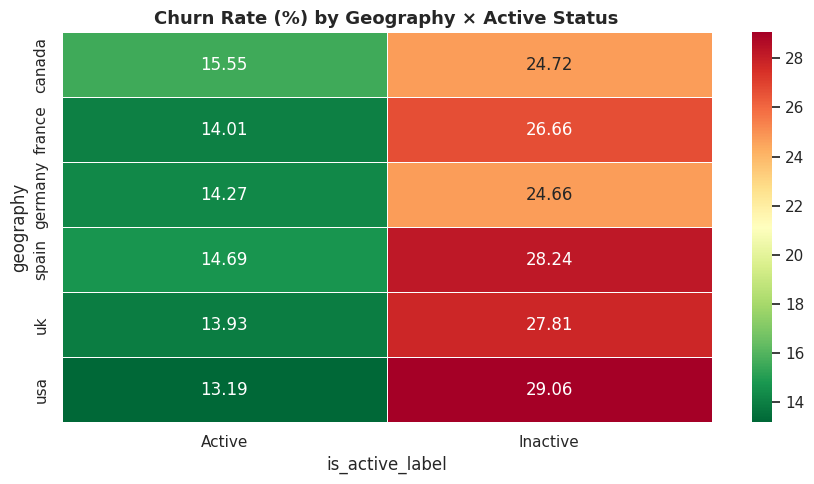

In [111]:
pivot_gi = df_final.pivot_table(
    index='geography', columns='is_active_label',
    values='churned', aggfunc='mean'
).mul(100).round(2)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_gi, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Churn Rate (%) by Geography × Active Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

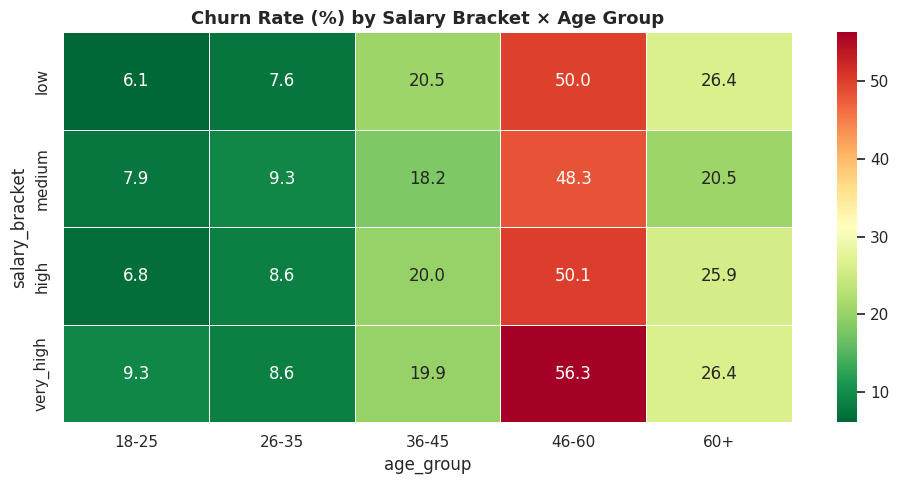

In [112]:
pivot_sa = df_final.pivot_table(
    index='salary_bracket', columns='age_group',
    values='churned', aggfunc='mean'
).mul(100).round(2)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_sa, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Churn Rate (%) by Salary Bracket × Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Analysis

In [113]:
corr_cols = ['age', 'salary', 'tenure', 'balance', 'num_products',
             'has_credit_card', 'is_active', 'churned']
corr_df = df_final[corr_cols].corr()
corr_df

,age,salary,tenure,balance,num_products,has_credit_card,is_active,churned
age,1.000000,-0.007201,-0.009997,-0.012822,-0.030680,-0.011721,0.085472,0.285323
salary,-0.007201,1.000000,0.007784,-0.001856,0.014204,-0.009933,-0.011421,0.012097
tenure,-0.009997,0.007784,1.000000,0.005827,0.013444,0.022583,-0.028362,-0.014001
balance,-0.012822,-0.001856,0.005827,1.000000,-0.001027,0.006721,-0.020418,0.017208
num_products,-0.030680,0.014204,0.013444,-0.001027,1.000000,0.003183,0.009612,-0.047820
has_credit_card,-0.011721,-0.009933,0.022583,0.006721,0.003183,1.000000,-0.011866,-0.007138
is_active,0.085472,-0.011421,-0.028362,-0.020418,0.009612,-0.011866,1.000000,-0.156128
churned,0.285323,0.012097,-0.014001,0.017208,-0.047820,-0.007138,-0.156128,1.000000


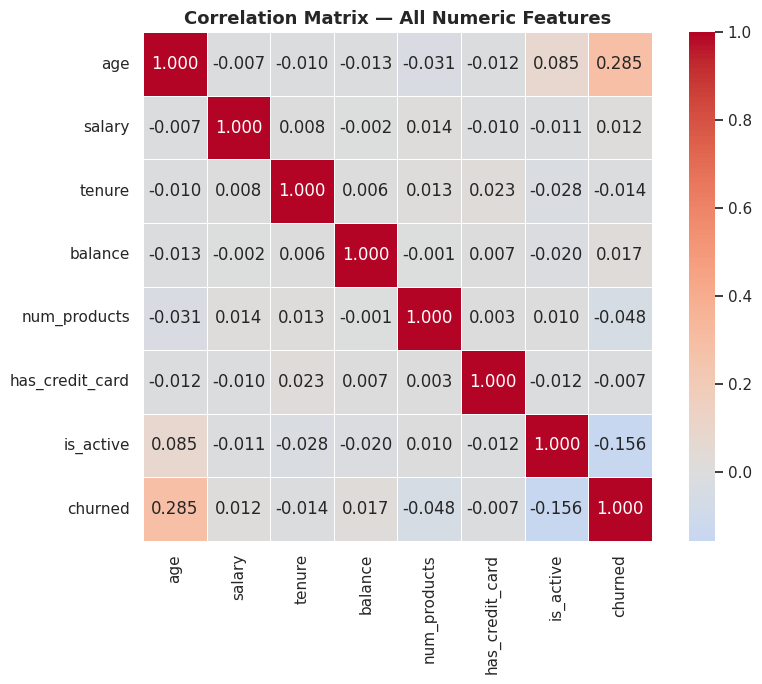

In [114]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_df, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Correlation Matrix — All Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

,Feature,|Correlation with Churned|
0,age,0.285323
1,is_active,0.156128
2,num_products,0.047820
3,balance,0.017208
4,tenure,0.014001
5,salary,0.012097
6,has_credit_card,0.007138


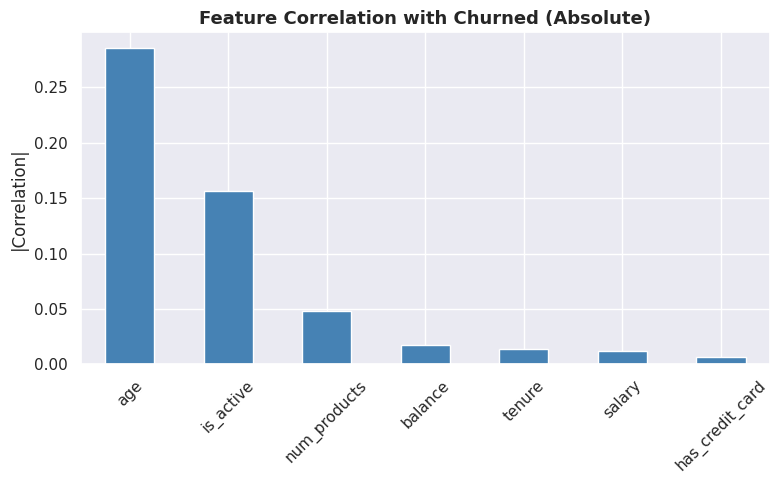

In [115]:
corr_with_target = (
    corr_df['churned']
    .drop('churned')
    .abs()
    .sort_values(ascending=False)
)
display(corr_with_target.reset_index().rename(
    columns={'index': 'Feature', 'churned': '|Correlation with Churned|'}
))

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Feature Correlation with Churned (Absolute)', fontsize=13, fontweight='bold')
ax.set_ylabel('|Correlation|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

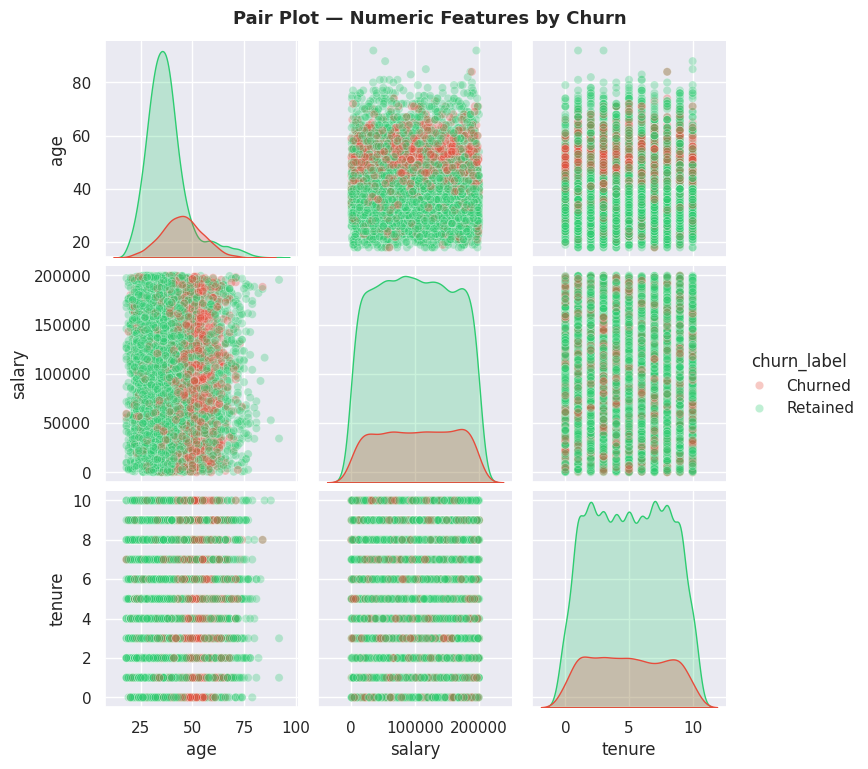

In [116]:
sns.pairplot(
    df_final[['age', 'salary', 'tenure', 'churn_label']].dropna(),
    hue='churn_label', diag_kind='kde', plot_kws={'alpha': 0.3},
    palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'}
)
plt.suptitle('Pair Plot — Numeric Features by Churn', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [122]:
# ============================================================
# SAVE: Export preprocessed DataFrame to CSV
# ============================================================
import os

output_csv = os.path.join(os.path.dirname(os.path.abspath(
    __vsc_ipynb_file__ if '__vsc_ipynb_file__' in dir() else 'eda_fe.ipynb'
)), 'preprocessed.csv')

df_final.to_csv(output_csv, index=False)
print(f'Saved preprocessed CSV to : {output_csv}')
print(f'Shape                     : {df_final.shape}')
print(f'Columns                   : {list(df_final.columns)}')


Saved preprocessed CSV to : /content/drive/MyDrive/Churn_modelling/preprocessed.csv
Shape                     : (10000, 37)
Columns                   : ['customer_id', 'name', 'gender', 'age', 'salary', 'location_id', 'churned', 'account_id', 'tenure', 'balance', 'num_products', 'has_credit_card', 'is_active', 'geography', 'age_group', 'salary_bracket', 'tenure_group', 'has_balance', 'churn_label', 'has_credit_card_label', 'is_active_label', 'balance_to_salary', 'balance_per_product', 'age_when_joined', 'products_per_tenure', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'engagement_score', 'high_risk_inactive', 'is_female', 'geo_france', 'geo_germany', 'geo_spain', 'geo_uk', 'geo_usa']
